# Prédiction des mouvements de fin de session du marché actions américain
## Challenge Data ENS – Challenge 84 *CFM*
### Master 2 IEF 2025/2026 – Machine Learning - Dhelia CHERIFI et Marie ABBYAD

## 0. Import des packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Sklearn - preprocessing & pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold

# Modèles de référence
from sklearn.linear_model import LogisticRegression

# Méthodes ensemblistes
from sklearn.ensemble import RandomForestClassifier

from sklearn.inspection import permutation_importance

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Métriques
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

## 1. Présentation de la problématique et stratégie

### 1.1 Le challenge 84 : Prédiction des rendements de fin de session du marché américain par CFM

**Objectif** : prédire la classe `reod`, c'est-à-dire la **direction du mouvement de prix entre 14h et 16h** sur le marché actions américain, à partir de l'historique intraday observé entre **9h30 et 14h**.


### 1.2 Structure des données

Les données sont organisées de la sorte :

**Variables d'entrée** :
- `ID` : identifiant unique de la ligne ;
- `day` : identifiant du jour ;
- `equity` : identifiant de l'action ;
- `r0` à `r52` : rendements sur des fenêtres de **5 minutes** entre **9h30 et 14h00**.

**Variable cible** :
- `reod` : classe du rendement de fin de journée sur la fenêtre **14h00–16h00**. La cible est **multiclasse** à 3 modalités :

    - `-1` : baisse nette de plus de **25 bps** ;
    - `0` : variation modérée entre **-25 et +25 bps** ;
    - `1` : hausse nette de plus de **25 bps**.

    Avec la variation étant : $$\frac{P_{16h} - P_{14h}}{P_{14h}} * 10^4$$

### 1.3 Métrique d'évaluation

La métrique imposée par le challenge n'est pas explicitement mentionnée. Nous utiliserons l'**accuracy**, et comme il s'agit d'une classification à 3 classes, nous suivons aussi la **balanced accuracy** et le **f1-score macro** pour mieux juger la qualité des modèles lorsque certaines classes sont moins fréquentes. Nous utiliserons également l'**AUC** multi-class.

En effet, une forte accuracy peut simplement indiquer une bonne prédiction de la classe majoritaire. La balanced accuracy permet de corriger ce biais en faisant la moyenne des taux de bonne classification pour chacune des classes. Le f1-score macro permet de mesurer un compromis entre précision et rappel ce qui permet d'évaluer les performances du modèle équilibrement entre les classes indépendamment de leur fréquence dans les données. Enfin l'AUC permet d'évaluer la capacité du modèle à discriminer chacune des classes contre les autres.

### 1.4 Stratégie

Notre stratégie est la suivante :
1. construire des features à partir de la trajectoire intraday `r0` à `r52` ;
2. utiliser un **split** pour valider nos modèles : split train / val ;
3. comparer plusieurs familles de modèles : 
    3.1. modèle non supervisé (K-Means);
    3.2. modèles supervisés (Random Forest et Hist Gradient Boosting)
4. interpréter les résultats.

## 2. Chargement des données et split train / validation / test

### 2.1 Chargement des données

In [ ]:
X_train_full = pd.read_csv("input_training.csv")
Y_train_full = pd.read_csv("output_training_gmEd6Zt.csv")
X_test_challenge = pd.read_csv("input_test.csv")

print("X_train shape :", X_train_full.shape)
print("Y_train shape :", Y_train_full.shape)
print("X_test  shape :", X_test_challenge.shape)

X_train shape : (843299, 56)
Y_train shape : (843299, 2)
X_test  shape : (885799, 56)


In [ ]:
X_train_full.head(5)

,ID,day,equity,r0,r1,r2,r3,r4,r5,r6,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
0,0,249,1488,0.00,NaN,NaN,NaN,0.00,NaN,NaN,...,0.00,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00
1,1,272,107,-9.76,0.00,-12.21,46.44,34.08,0.00,41.24,...,-4.83,-16.92,-4.84,4.84,0.00,7.26,-9.68,-19.38,9.71,26.68
2,2,323,1063,49.85,0.00,0.00,-26.64,-23.66,-22.14,49.12,...,-6.37,1.59,6.37,-49.32,-9.59,-6.40,22.41,-6.39,7.99,15.96
3,3,302,513,0.00,NaN,0.00,0.00,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
4,4,123,1465,-123.84,-115.18,-26.44,0.00,42.42,10.56,0.00,...,-5.36,-21.44,-21.48,10.78,-21.55,-5.40,-10.81,5.41,-32.47,43.43


In [ ]:
Y_train_full.head(5)

,ID,reod
0,0,0
1,1,0
2,2,-1
3,3,0
4,4,-1


In [ ]:
print("Proportion de -1, 0 et 0 dans Y_train : ")
print(Y_train_full["reod"].value_counts(normalize=True).sort_index().round(4))

Proportion de -1, 0 et 0 dans Y_train : 
reod
-1    0.3008
 0    0.4120
 1    0.2872
Name: proportion, dtype: float64


Le jeu d’entraînement contient **843 299 observations** et **56 variables**, incluant les identifiants (`ID`, `day`, `equity`) ainsi que les **53 rendements intraday** mesurés toutes les 5 minutes.

La variable cible `reod` prend trois modalités :
- **-1** : baisse du prix  
- **0** : variation faible  
- **1** : hausse du prix  

La distribution des classes est relativement équilibrée :
- -1 : 30.08%  
- 0 : 41.20%  
- 1 : 28.72%  

La classe centrale est légèrement majoritaire, ce qui est cohérent avec le comportement des marchés financiers où les variations importantes restent moins fréquentes.

On observe également la présence de valeurs manquantes dans certaines variables, qui devront être traitées ultérieurement.

### 2.2 Split train / validation / test

In [ ]:
df = X_train_full.merge(Y_train_full, on='ID')
print("Dataset complet :", df.shape)
print("Colonnes :", df.columns.tolist())

Dataset complet : (843299, 57)
Colonnes : ['ID', 'day', 'equity', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52', 'reod']


In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['reod'])

print(f"Train : {len(train_df)} obs")
print(f"Val : {len(val_df)} obs")
print()
print("Distribution de train :")
print(train_df["reod"].value_counts(normalize=True).sort_index().round(4))
print()
print("Distribution de validation :")
print(val_df["reod"].value_counts(normalize=True).sort_index().round(4))

Train : 674639 obs
Val : 168660 obs

Distribution de train :
reod
-1    0.3008
 0    0.4120
 1    0.2872
Name: proportion, dtype: float64

Distribution de validation :
reod
-1    0.3008
 0    0.4120
 1    0.2872
Name: proportion, dtype: float64


Le jeu d’entraînement est divisé en :
- **Train** : 80% (674 639 observations)  
- **Validation** : 20% (168 660 observations)  

Le split est réalisé avec une **stratification sur la variable cible `reod`**, ce qui permet de conserver exactement la même distribution des classes dans les deux sous-échantillons.

Cette approche garantit une évaluation fiable des modèles et limite les biais liés à un éventuel déséquilibre de classes.

## 3. Construction des features 

### 3.1 Stratégie de construction des features

Nous avons des rendements toutes les 5 minutes et utiliserons ainsi les features suivantes :


derniers rendements observés (`r_last`, `r_last_3_mean`) 
moyenne cumulée sur le début, le milieu et la fin de matinée 
écart-type global, par blocs, amplitude max-min 
pente linéaire, skewness, kurtosis 
part de rendements positifs / négatifs 
moyenne par `day`, moyenne par `equity`, écart à la moyenne du jour 

In [ ]:
def autocorr(x, lag=1):
    x = np.asarray(x, dtype=float)
    if len(x) <= lag or np.std(x) == 0:
        return 0.0
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]


def compute_slope(arr):
    arr = np.asarray(arr, dtype=float)
    x = np.arange(len(arr))
    if np.std(arr) == 0:
        return 0.0
    return np.polyfit(x, arr, 1)[0]


def build_features(df):
    return_cols = sorted(
        [col for col in df.columns if col.startswith("r") and col[1:].isdigit()],
        key=lambda x: int(x[1:])
    )

    r = df[return_cols].copy()
    feats = pd.DataFrame(index=df.index)

    feats["ret_mean"] = r.mean(axis=1)
    feats["ret_std"] = r.std(axis=1)
    feats["ret_min"] = r.min(axis=1)
    feats["ret_max"] = r.max(axis=1)
    feats["max_minus_min"] = feats["ret_max"] - feats["ret_min"]

    half_len = len(return_cols) // 2
    feats["sum_first_half"] = r.iloc[:, :half_len].sum(axis=1)
    feats["sum_second_half"] = r.iloc[:, half_len:].sum(axis=1)
    feats["sum_diff_halves"] = feats["sum_second_half"] - feats["sum_first_half"]

    feats["mean_last_5_obs"] = r.iloc[:, -5:].mean(axis=1)
    feats["first_return_obs"] = r.iloc[:, 0]
    feats["last_return_obs"] = r.iloc[:, -1]
    feats["last_minus_first"] = feats["last_return_obs"] - feats["first_return_obs"]

    # Ici, on ne peut pas mettre r >, < ou = à 0 puique notre règle définie est >25bps, <-25bps
    # ou entre les deux, nous définissons donc positif, negatif ou mid par cette même règle
    feats["pos_ratio"] = (r > 25).mean(axis=1)
    feats["neg_ratio"] = (r < -25).mean(axis=1)
    feats["mid_ratio"] = ((r >= -25) & (r <= 25)).mean(axis=1)

    feats["ret_abs_mean"] = r.abs().mean(axis=1)

    feats["slope_all"] = r.apply(lambda row: compute_slope(row.values), axis=1)
    feats["autocorr_1"] = r.apply(lambda row: autocorr(row.values, lag=1), axis=1)

    signs = np.sign(r.values)
    feats["sign_changes"] = (signs[:, 1:] != signs[:, :-1]).sum(axis=1)

    return feats

In [ ]:
train_feats = build_features(train_df)
val_feats = build_features(val_df)

X_train = train_feats
y_train = train_df["reod"]

X_val = val_feats
y_val = val_df["reod"]

### 3.2 Description statistique des features

In [ ]:
feats_stats = X_train.describe().T
feats_stats["skew"] = X_train.skew()
feats_stats["kurtosis"] = X_train.kurtosis()

feats_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
ret_mean,673027.0,31.973579,8039.843266,-1.965320e+03,-2.319245,-0.123019,1.689434,4.170943e+06,354.893212,151827.431219
ret_std,671129.0,265.144119,57929.445882,0.000000e+00,13.575348,20.484248,32.682197,3.036493e+07,361.815016,157555.945578
ret_min,673027.0,-101.203297,204.320583,-9.973540e+03,-93.460000,-54.950000,-33.560000,1.827200e+03,-9.245132,177.198823
ret_max,673027.0,1746.324147,417179.631825,-1.965320e+03,32.660000,53.040000,86.960000,2.210600e+08,368.903877,163350.002740
max_minus_min,673027.0,1847.527444,417179.479557,0.000000e+00,73.420000,115.030000,187.310000,2.210601e+08,368.903895,163350.050266
sum_first_half,674639.0,1640.563948,416791.126488,-1.988859e+04,-89.840000,-3.670000,67.230000,2.210600e+08,369.066683,163568.844511
sum_second_half,674639.0,-1.752883,107.927118,-3.452600e+03,-42.230000,0.000000,40.200000,6.631810e+03,1.521014,116.171451
sum_diff_halves,674639.0,-1642.316830,416791.108166,-2.210600e+08,-80.130000,3.750000,101.320000,1.991176e+04,-369.066693,163568.868310
mean_last_5_obs,643771.0,0.072325,12.104567,-9.909900e+02,-3.006000,0.000000,3.270000,1.168480e+03,-1.290259,547.081917
first_return_obs,638080.0,1406.478727,405023.053518,-9.967670e+03,-30.570000,0.000000,21.330000,2.210600e+08,405.960676,190710.080452


Les statistiques descriptives ont été calculées sur l’ensemble des variables explicatives construites à partir des rendements intraday.

### Analyse des premiers moments

Nous pouvons observer une important hétérogénité dans nos données, en effet, certains features ont une moyenne proche de 0 tandis que d'autres ont des moyennes très importantes notamment **max_minus_min** (1847), **ret_max** (1746) et **sum_diff_halves** (-1642). De plus, les écarts-types sont parfois extrêmes avec certaines features dont l'écart-type dépasse 400000.

### Analyse de la distribution

Les données présentent une importante asymétrie comme le démontre le Skewness dont la valeur absolue dépasse 400 pour certaines features. Cela indique une importante concentration de nos données accompagnée de longues queues de distribution. Par ailleurs, le kurtosis présente lui aussi des valeurs extrêmes pour certaines features dépassant parfois 200000 indiquant la présence de queues épaisses et d'un nombre important d'observations extrêmes. 

Nous ne sommes ainsi pas dans le cadre gaussien ce qui est attendu dans un cadre financier. Au vu de nos données extrêmes nous aurons besoin de les normaliser.

### Interprétation financière

Ces résultats sont cohérents avec les propriétés stylisées des marchés financiers :
- distributions non normales  
- volatilité importante  
- présence d’événements extrêmes  

Ces caractéristiques justifient l’utilisation de modèles de machine learning, capables de capturer des relations non linéaires et complexes entre les variables explicatives et la variable cible.

Nous observons par ailleurs que nous avons des valeurs manquantes pour certaines features notamment pour **slope_all** et **autcorr_1** dont 28% des données sont manquantes. Nous devrons ainsi imputer une valeur notamment la médiane pour les valeurs manquantes des features. 

## 4. Modèle de référence

### 4.1 Régression logistique

Notre variable objectif peut avoir trois valeurs (`-1`, `0` ou `1`) correspondant à un cas de **classification multi-classe**. Afin de construire un modèle simple de référence, nous faisons une régression logistique.

Nous commencons par mettre à l'échelle nos variables explicatives. En effet, certains features comme `ret_range` ou `last_minus_first` peuvent avoir des valeurs très élévées en valeur absolue (leur moyenne respective étant de 1847 et -1270) tandis que d'autres ont des valeurs bien plus faibles comme `pos_ratio`, `neg_ratio` et `mid_ratio` qui ont des valeurs comprises entre 0 et 1. Sans normalisation, les variables de plus grande amplitude domineraient artificiellement les autres dans l'apprentissage du modèle. Nous centrons et réduisons ainsi nos variables pour les rendre comparables entre elles.

En revanche, nous devons faire le fit_transform **uniquement** sur `train_df` et non sur `val_df` pour ne pas avoir de surapprentissage. Nous appliquons seulement le scalar de `train_df` sur `val_df`.

De plus, nous sommes en présence de NaN et imputons à ces valeurs la médiane de la feature. 

In [ ]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

train_imputed = imputer.fit_transform(X_train)
val_imputed = imputer.transform(X_val)

train_scaled = scaler.fit_transform(train_imputed)
val_scaled = scaler.transform(val_imputed)

In [ ]:
def compute_multiclass_auc(model, X_eval, y_eval):
    y_proba = model.predict_proba(X_eval)
    class_labels = getattr(model, 'classes_', None)
    if class_labels is None:
        class_labels = np.sort(np.unique(y_eval))
    return roc_auc_score(
        y_eval,
        y_proba,
        average='macro',
        multi_class='ovr',
        labels=class_labels)

In [ ]:
logreg = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=500,
    class_weight='balanced',
    random_state=42
)

logreg.fit(train_scaled, y_train)

y_pred_logreg_base_train = logreg.predict(train_scaled)
y_pred_logreg_base_val = logreg.predict(val_scaled)

acc_train_logreg_base = accuracy_score(y_train, y_pred_logreg_base_train)
acc_val_logreg_base = accuracy_score(y_val, y_pred_logreg_base_val)
bacc_val_logreg_base = balanced_accuracy_score(y_val, y_pred_logreg_base_val)
f1_val_logreg_base = f1_score(y_val, y_pred_logreg_base_val, average='macro')
auc_val_logreg_base = compute_multiclass_auc(logreg, val_scaled, y_val)

print(f'Accuracy train      : {acc_train_logreg_base:.4f}')
print(f'Accuracy val        : {acc_val_logreg_base:.4f}')
print(f'Balanced accuracy   : {bacc_val_logreg_base:.4f}')
print(f'Macro-F1            : {f1_val_logreg_base:.4f}')
print(f'AUC multiclass      : {auc_val_logreg_base:.4f}')
print(f'Écart train et val  : {acc_train_logreg_base - acc_val_logreg_base:.4f}')

Accuracy train      : 0.4578
Accuracy val        : 0.4586
Balanced accuracy   : 0.4337
Macro-F1            : 0.4279
AUC multiclass      : 0.6453
Écart train et val  : -0.0009


Nous observons un faible écart entre l'accuracy train et validation qui est en faveur du modèle puisque l'écart est négatif ce qui indique que nous ne sommes pas dans un cas de surapprentissage. Nous observons néanmoins que la balanced accuracy et la macro f1 sont plus faibles que l'accuracy ce qui indique un déséquilibre entre les performances des classes, le macro f1 suggère donc soit un manque de détection de certaines classes soit un excès de faux positifs. Il est important de noter que nous obtenons une AUC importante qui indique une capacité de discrimination non négligeable entre les classes.

Nous allons faire une sélection du meilleur paramètre C soit le paramètre de régularisation qui permet de faire le meilleur compromis entre biais et variance. Un faible C indique une forte régularisation et donc un modèle plutôt simple alors qu'un C important indique une plus grande flexibilité dans le modèle.

In [ ]:
logreg_cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_cv = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=500, class_weight='balanced', random_state=42))
])

param_grid_logreg = {'logreg__C': [0.001, 0.01, 0.1, 1.0, 10.0]}

grid_logreg = GridSearchCV(
    logreg_cv,
    param_grid_logreg,
    cv=logreg_cv_splitter,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(train_feats, y_train)

print(f"Meilleur C : {grid_logreg.best_params_['logreg__C']}")
print(f"Meilleur score CV : {grid_logreg.best_score_:.4f}")

best_logreg = grid_logreg.best_estimator_
y_pred_best_logreg_train = best_logreg.predict(train_feats)
y_pred_best_logreg = best_logreg.predict(val_feats)

acc_train_logreg = accuracy_score(y_train, y_pred_best_logreg_train)
acc_logreg_best = accuracy_score(y_val, y_pred_best_logreg)
bacc_logreg_best = balanced_accuracy_score(y_val, y_pred_best_logreg)
f1_logreg_best = f1_score(y_val, y_pred_best_logreg, average='macro')
auc_logreg_best = compute_multiclass_auc(best_logreg, val_feats, y_val)

print(f'Accuracy train (meilleur C)      : {acc_train_logreg:.4f}')
print(f'Accuracy validation (meilleur C) : {acc_logreg_best:.4f}')
print(f'Écart train et val               : {acc_train_logreg - acc_logreg_best:.4f}')
print(f'Balanced accuracy val            : {bacc_logreg_best:.4f}')
print(f'Macro-F1 val                     : {f1_logreg_best:.4f}')
print(f'AUC multiclass val               : {auc_logreg_best:.4f}')

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Meilleur C : 0.001
Meilleur score CV : 0.4575
Accuracy train (meilleur C)      : 0.4580
Accuracy validation (meilleur C) : 0.4589
Écart train et val               : -0.0009
Balanced accuracy val            : 0.4338
Macro-F1 val                     : 0.4280
AUC multiclass val               : 0.6453


Nous obtenons des résultats similaires que précédemment.

Nos résultats reflètent la complexité du problème multi-classe et surtout la difficulté à prévoir précisément les mouvements financiers  qu'ils soient faibles (classe 0), en hausses ou en baisses.

Nous obtenons le meilleur modèle pour un parmètre C = 0.001. 
Nous pouvons remarquer que l'accuracy du set de validation s'est en effet amélioré de 0.0003 en passant de 0.4586 pour C=0.1 à 0.4589. L'écart s'est donc légérement accentué puisque l'accuracy du train était légérement inférieure à celle de validation, l'écart est de -0.0011 ce qui reste très faible et indique que nous ne sommes pas dans un cas de surapprentissage. De plus, l'accuracy s'est améliorée, avec une autre seed nous pourrions avoir un résultat différent mais nous restons le bon ordre de grandeur ce qui est rassurant quant à notre modèle.

In [ ]:
coef_abs = np.abs(best_logreg.named_steps['logreg'].coef_).mean(axis=0)
coef_df = pd.DataFrame({
    'feature': train_feats.columns,
    'coef_abs_mean': coef_abs
}).sort_values('coef_abs_mean', ascending=False).head(15)

coef_df

,feature,coef_abs_mean
14,mid_ratio,0.230936
13,neg_ratio,0.226317
12,pos_ratio,0.200883
18,sign_changes,0.014792
17,autocorr_1,0.008954
8,mean_last_5_obs,0.007037
6,sum_second_half,0.006834
11,last_minus_first,0.005754
16,slope_all,0.003261
15,ret_abs_mean,0.002623


Les variables les plus importantes sont liées à la structure des rendements intraday (ratios positifs/négatifs, changements de signe, autocorrélation).

Cela suggère que la dynamique de microstructure et les déséquilibres intraday jouent un rôle clé dans la formation du prix en fin de séance.

## 5. Modèle non supervisé : K-Means

### 5.1 Objectif du clustering dans ce contexte

Le clustering ne prédit pas directement la cible `reod`, mais il permet :
1. d'identifier des **profils intraday** similaires ;
2. de vérifier si certains régimes de trajectoire `r0...r52` sont associés à davantage de baisses, de neutralité ou de hausses ;
3. de construire une feature de cluster réutilisable dans les modèles supervisés.

Nous commencons par préparer nos données en les standardisant pour les mêmes raisons que dans la partie précédente, nous le faisons afin d'éviter que certaines features dominent artificiellement les autres à cause de leur amplitude. Cela permet également de pouvoir comparer les features les unes avec les autres. 

In [ ]:
R_COLS = sorted([c for c in train_df.columns if c.startswith('r') and c[1:].isdigit()], key=lambda x: int(x[1:]))

X_cluster = train_df[R_COLS].fillna(0).values
print(f'Données de clustering : {X_cluster.shape}')

scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

Données de clustering : (674639, 53)


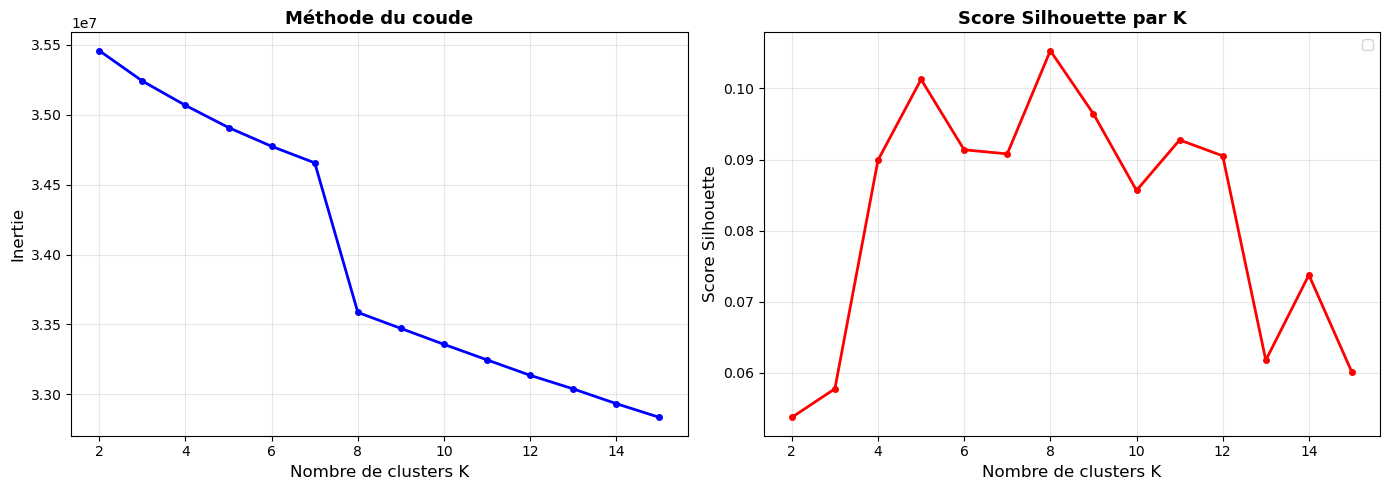

In [ ]:
inertia = []
sil_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, max_iter=300, random_state=42)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_, sample_size=5000, random_state=42))

# ─── Graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia, 'b.-', linewidth=2, markersize=8)
axes[0].set_xlabel("Nombre de clusters K", fontsize=12)
axes[0].set_ylabel("Inertie", fontsize=12)
axes[0].set_title("Méthode du coude", fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 'r.-', linewidth=2, markersize=8)
axes[1].set_xlabel("Nombre de clusters K", fontsize=12)
axes[1].set_ylabel("Score Silhouette", fontsize=12)
axes[1].set_title("Score Silhouette par K", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Les résultats obtenus indiquent pour la méthode du coude une cassure entre K = 7 et K = 8. Le graphique de silhouette nous indique ici un maximum global pour K = 8, ce qui est cohérent avec le graphique de la méthode du coude. En revanche, il est important de noter qu'au vu de la taille de nos données, nous avons pris un sous-échantillon pour le score silhouette ce qui permet de réduire drastiquement le temps d'exécution, pour stabiliser nos résultats, nous avons ajouter une seed également. 

In [ ]:
K_OPTIMAL = 8

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    max_iter=500,
    random_state=42
)
kmeans_final.fit(X_cluster_scaled)

print(f"K-Means ajusté avec K={K_OPTIMAL}")
print(f"Inertie finale : {kmeans_final.inertia_:.2f}")

cluster_labels_train = kmeans_final.labels_
cluster_counts = pd.Series(cluster_labels_train).value_counts().sort_index()
print("\nNombre d'observations par cluster :")
print(cluster_counts.to_string())

K-Means ajusté avec K=8
Inertie finale : 33585929.65

Nombre d'observations par cluster :
0     66725
1     57340
2     47906
3     55412
4    385640
5         3
6     61611
7         2


Au vu du résultat de la silhouette, nous essayons pour K = 8, en revanche, nous obtenons deux clusters (5 et 7) avec 2 et 3 observations ce qui n'est pas proportionnel avec les autres clusters et bien trop peu donc inexploitable. Ainsi nous utiliserons K = 7 comme le préconise la règle du coude.

Cette situation met en évidence une limite classique des méthodes de clustering sur des données financières : la présence de quelques observations atypiques peut conduire à la formation de clusters très peu peuplés, qui ne correspondent pas à de véritables régimes de marché mais plutôt à du bruit ou à des comportements extrêmes.

Le choix de K = 7 permet ainsi d’obtenir une segmentation plus stable et équilibrée, garantissant une meilleure interprétabilité des groupes et une exploitation plus pertinente dans la suite de l’analyse.

In [ ]:
K_OPTIMAL = 7

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    max_iter=500,
    random_state=42
)
kmeans_final.fit(X_cluster_scaled)

print(f"K-Means ajusté avec K={K_OPTIMAL}")
print(f"Inertie finale : {kmeans_final.inertia_:.2f}")

cluster_labels_train = kmeans_final.labels_
cluster_counts = pd.Series(cluster_labels_train).value_counts().sort_index()
print("\nNombre d'observations par cluster :")
print(cluster_counts.to_string())

K-Means ajusté avec K=7
Inertie finale : 34655919.10

Nombre d'observations par cluster :
0     32725
1     68701
2     39718
3    377843
4     42904
5     53569
6     59179


Les clusters ont cette fois suffisament d'observations.

La répartition des observations entre les différents clusters est désormais beaucoup plus équilibrée, ce qui rend cette segmentation exploitable. Aucun cluster n’est marginal ou composé de quelques points seulement, ce qui garantit une meilleure robustesse de l’analyse.

On observe toutefois qu’un cluster (cluster 3) regroupe une part importante des observations. Cela peut indiquer l’existence d’un régime de marché dominant, tandis que les autres clusters capturent des comportements plus spécifiques ou moins fréquents.

Cette structure est cohérente avec les données financières, où certaines dynamiques intraday sont récurrentes, tandis que d’autres correspondent à des situations plus particulières (forte volatilité, retournements, etc.).

Répartition des classes par cluster :
target       -1       0       1
cluster                        
0        0.3526  0.3049  0.3425
1        0.3394  0.3271  0.3334
2        0.3631  0.2866  0.3502
3        0.2635  0.4881  0.2484
4        0.3451  0.2941  0.3608
5        0.3590  0.3322  0.3088
6        0.3384  0.3262  0.3354


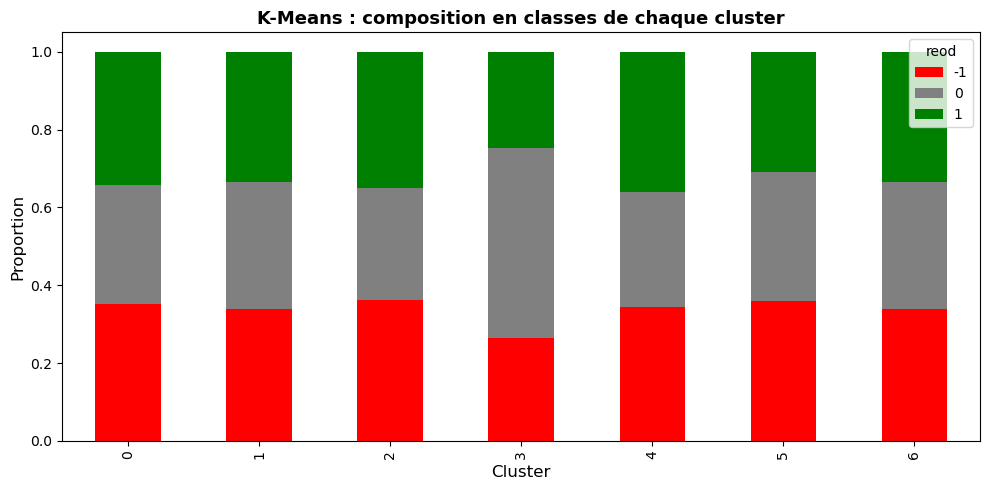

In [ ]:
# ─────────────────────────────────────────────────────────────
# 5.5 Lien entre clusters et variable cible
# ─────────────────────────────────────────────────────────────
cluster_analysis = pd.DataFrame({
    'cluster': cluster_labels_train,
    'target':  y_train
})

cluster_stats = pd.crosstab(cluster_analysis['cluster'], cluster_analysis['target'], normalize='index')
cluster_stats = cluster_stats.reindex(columns=[-1, 0, 1], fill_value=0)
print('Répartition des classes par cluster :')
print(cluster_stats.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cluster_stats.plot(kind='bar', stacked=True, ax=ax, color=['red', 'gray', 'green'])
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('K-Means : composition en classes de chaque cluster', fontsize=13, fontweight='bold')
ax.legend(title='reod')
plt.tight_layout()
plt.show()

L’analyse de la composition des clusters en fonction de la variable cible `reod` montre que les groupes identifiés par K-Means ne sont pas neutres vis-à-vis de la direction de fin de séance.

On observe notamment que le **cluster 3** se distingue nettement des autres, avec une proportion beaucoup plus élevée de classe **0** (48.81%) et des proportions plus faibles de hausses et de baisses. Ce cluster semble donc correspondre à un régime intraday davantage associé à une **stabilité du prix en fin de séance**. C'est par ailleurs le plus gros cluster puisqu'il est composé de 377 843 observations soit plus de la moitié de nos données.

À l’inverse, les clusters **0, 2, 4 et 5** présentent une proportion plus importante de classes extrêmes (-1 ou 1), ce qui suggère qu’ils regroupent des profils intraday plus directionnels, davantage liés à des mouvements de hausse ou de baisse.

Cependant, les écarts entre clusters restent modérés dans l’ensemble : aucun cluster n’est associé exclusivement à une seule classe. Cela indique que le clustering capte bien une certaine structure des trajectoires intraday, mais que cette structure ne suffit pas, à elle seule, à prédire parfaitement la variable cible.

Ces résultats restent néanmoins intéressants, car ils montrent que l’appartenance à un cluster contient une **information partielle** sur le régime de marché. Cette information pourra donc être réutilisée comme **feature supplémentaire** dans les modèles supervisés.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 5.6 Features K-Means pour la logistique
# ─────────────────────────────────────────────────────────────
base_logistic_model = best_logreg
best_regularization_C = best_logreg.named_steps['logreg'].C


def build_cluster_feature_sets(train_features, val_features, train_dataframe, val_dataframe, return_columns, scaler, fitted_kmeans):
    train_returns = train_dataframe[return_columns].fillna(0).values
    val_returns = val_dataframe[return_columns].fillna(0).values

    train_returns_scaled = scaler.transform(train_returns)
    val_returns_scaled = scaler.transform(val_returns)

    train_cluster_labels = fitted_kmeans.predict(train_returns_scaled)
    val_cluster_labels = fitted_kmeans.predict(val_returns_scaled)

    train_cluster_distances = fitted_kmeans.transform(train_returns_scaled)
    val_cluster_distances = fitted_kmeans.transform(val_returns_scaled)

    # Variante 1: id de cluster brut
    train_with_cluster_id = train_features.copy()
    val_with_cluster_id = val_features.copy()
    train_with_cluster_id['kmeans_cluster_id'] = train_cluster_labels
    val_with_cluster_id['kmeans_cluster_id'] = val_cluster_labels

    # Variante 2: one-hot cluster
    train_cluster_onehot = pd.get_dummies(pd.Series(train_cluster_labels, name='cluster_label'), prefix='cluster')
    val_cluster_onehot = pd.get_dummies(pd.Series(val_cluster_labels, name='cluster_label'), prefix='cluster')
    train_cluster_onehot, val_cluster_onehot = train_cluster_onehot.align(val_cluster_onehot, axis=1, fill_value=0)

    train_with_cluster_onehot = pd.concat([train_features.reset_index(drop=True), train_cluster_onehot.reset_index(drop=True)], axis=1)
    val_with_cluster_onehot = pd.concat([val_features.reset_index(drop=True), val_cluster_onehot.reset_index(drop=True)], axis=1)

    # Variante 3: distances aux centroïdes
    n_clusters = train_cluster_distances.shape[1]
    distance_column_names = [f'cluster_distance_{cluster_index}' for cluster_index in range(n_clusters)]

    train_distance_features = pd.DataFrame(train_cluster_distances, columns=distance_column_names)
    val_distance_features = pd.DataFrame(val_cluster_distances, columns=distance_column_names)

    train_with_cluster_distances = pd.concat([train_features.reset_index(drop=True), train_distance_features], axis=1)
    val_with_cluster_distances = pd.concat([val_features.reset_index(drop=True), val_distance_features], axis=1)

    # Variante 4: one-hot + distances
    train_with_onehot_and_distances = pd.concat([train_with_cluster_onehot, train_distance_features], axis=1)
    val_with_onehot_and_distances = pd.concat([val_with_cluster_onehot, val_distance_features], axis=1)

    return {
        'Logistique + cluster_id': (train_with_cluster_id, val_with_cluster_id),
        'Logistique + cluster_onehot': (train_with_cluster_onehot, val_with_cluster_onehot),
        'Logistique + cluster_distances': (train_with_cluster_distances, val_with_cluster_distances),
        'Logistique + onehot + distances': (train_with_onehot_and_distances, val_with_onehot_and_distances),
    }


cluster_feature_sets = build_cluster_feature_sets(
    train_features=train_feats,
    val_features=val_feats,
    train_dataframe=train_df,
    val_dataframe=val_df,
    return_columns=R_COLS,
    scaler=scaler_clust,
    fitted_kmeans=kmeans_final,
)

In [ ]:
# ─────────────────────────────────────────────────────────────
# 5.6 bis Entraînement et comparaison des variantes
# ─────────────────────────────────────────────────────────────
def fit_logistic_pipeline(train_matrix, y_train_labels, regularization_C):
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            C=regularization_C,
            solver='lbfgs',
            max_iter=500,
            class_weight='balanced',
            random_state=42,
        )),
    ])
    model.fit(train_matrix, y_train_labels)
    return model


def summarize_classification_metrics(model, X_train_matrix, y_train_true, X_val_matrix, y_val_true):
    train_pred = model.predict(X_train_matrix)
    val_pred = model.predict(X_val_matrix)
    return {
        'acc_train': accuracy_score(y_train_true, train_pred),
        'acc_val': accuracy_score(y_val_true, val_pred),
        'bacc_val': balanced_accuracy_score(y_val_true, val_pred),
        'f1_val': f1_score(y_val_true, val_pred, average='macro'),
        'auc_val': compute_multiclass_auc(model, X_val_matrix, y_val_true),
    }


# Référence: logistique sans cluster (déjà entraînée)
base_logistic_model = best_logreg
base_logistic_results = summarize_classification_metrics(
    base_logistic_model,
    train_feats,
    y_train,
    val_feats,
    y_val,
)

variant_models = {}
variant_results = {}
for variant_name, (train_variant_matrix, val_variant_matrix) in cluster_feature_sets.items():
    variant_model = fit_logistic_pipeline(train_variant_matrix, y_train, best_regularization_C)
    variant_models[variant_name] = variant_model
    variant_results[variant_name] = summarize_classification_metrics(
        variant_model,
        train_variant_matrix,
        y_train,
        val_variant_matrix,
        y_val,
    )

best_variant_name = max(variant_results, key=lambda name: variant_results[name]['acc_val'])
best_logreg_cluster = variant_models[best_variant_name]
results_logreg_cluster = variant_results[best_variant_name]
results_logreg_base = base_logistic_results

print('Base (sans cluster)')
print(f"  Accuracy train      : {base_logistic_results['acc_train']:.4f}")
print(f"  Accuracy val        : {base_logistic_results['acc_val']:.4f}")
print(f"  Balanced accuracy   : {base_logistic_results['bacc_val']:.4f}")
print(f"  Macro-F1            : {base_logistic_results['f1_val']:.4f}")
print(f"  AUC multiclass      : {base_logistic_results['auc_val']:.4f}")
print()
print('Meilleure variante avec cluster')
print(f'  Modèle              : {best_variant_name}')
print(f"  Accuracy train      : {results_logreg_cluster['acc_train']:.4f}")
print(f"  Accuracy val        : {results_logreg_cluster['acc_val']:.4f}")
print(f"  Balanced accuracy   : {results_logreg_cluster['bacc_val']:.4f}")
print(f"  Macro-F1            : {results_logreg_cluster['f1_val']:.4f}")
print(f"  AUC multiclass      : {results_logreg_cluster['auc_val']:.4f}")

Base (sans cluster)
  Accuracy train      : 0.4580
  Accuracy val        : 0.4589
  Balanced accuracy   : 0.4338
  Macro-F1            : 0.4280
  AUC multiclass      : 0.6453

Meilleure variante avec cluster
  Modèle              : Logistique + onehot + distances
  Accuracy train      : 0.4607
  Accuracy val        : 0.4617
  Balanced accuracy   : 0.4386
  Macro-F1            : 0.4335
  AUC multiclass      : 0.6481


Nous testons ici plusieurs façons d’intégrer l’information issue de K-Means dans la régression logistique : sous forme d’**identifiant de cluster**, de **variables one-hot**, de **distances aux centroïdes**, ou d’une combinaison des deux.

L'utilisation d'un **identifiant de cluster** fournit une information simple mais impose un ordre artificiel entre les clusters qui n'a pas de sens économique dans notre contexte. La méthode **one-hot** permet de corriger ce biais en représentant chaque cluster comme une catégorie distincte, le numéro du cluster n'a plus d'impact. Les **distances aux centroïdes** apportent une information encore plus riche en capturant la proximité avec chaque cluster ce qui permet de modéliser plus finement les relations. La combinaison des deux permet d'enrichir l'information.

Les résultats montrent que la meilleure variante est **`Logistique + onehot + distances`**, avec une accuracy de validation de **0.4617**, contre **0.4589** pour le modèle logistique de base sans information de clustering. On observe cependant que le Balanced accuracy et le Macro-F1 sont bien inférieur au résultat de l'accuracy, ce qui suggère un déséquilibre entre les performances des classes. L’AUC est importante ce qui indique une capacité de discrimination non négligeable entre les classes néanmoins elle est légèrement inférieure à celle de la régression logistique.

L’amélioration reste modeste, mais elle est bien réelle et cohérente avec l’analyse précédente : les clusters ne suffisent pas à expliquer complètement la variable cible, mais ils capturent une partie de la structure intraday des données. Leur ajout apporte donc un **signal complémentaire** utile au modèle supervisé.

Le fait que la combinaison **one-hot + distances** soit la plus performante suggère que deux types d’information sont pertinents :
- l’**appartenance à un régime intraday** donné ;
- la **proximité à chacun des centroïdes**, qui fournit une information plus fine que le simple label de cluster.

Ces résultats confirment ainsi que le clustering peut être utilisé non seulement comme outil exploratoire, mais aussi comme source de **features additionnelles** pour améliorer légèrement la performance prédictive.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 5.7 Comparaison synthétique des variantes
# ─────────────────────────────────────────────────────────────
comparison_rows = [
    {
        'Modele': 'Logistique seule',
        'Acc_train': results_logreg_base['acc_train'],
        'Acc_val': results_logreg_base['acc_val'],
        'BAcc_val': results_logreg_base['bacc_val'],
        'F1_val': results_logreg_base['f1_val'],
        'AUC': results_logreg_base['auc_val'],
    }
]

for variant_name, variant_metrics in variant_results.items():
    comparison_rows.append({
        'Modele': variant_name,
        'Acc_train': variant_metrics['acc_train'],
        'Acc_val': variant_metrics['acc_val'],
        'BAcc_val': variant_metrics['bacc_val'],
        'F1_val': variant_metrics['f1_val'],
        'AUC': variant_metrics['auc_val'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['Delta_Acc_val_vs_base'] = comparison_df['Acc_val'] - results_logreg_base['acc_val']
comparison_df = comparison_df.sort_values(['Acc_val', 'F1_val'], ascending=False).reset_index(drop=True)
comparison_df


,Modele,Acc_train,Acc_val,BAcc_val,F1_val,AUC,Delta_Acc_val_vs_base
0,Logistique + onehot + distances,0.460747,0.461704,0.438625,0.433466,0.648115,0.002828
1,Logistique + cluster_onehot,0.460042,0.461431,0.437076,0.430380,0.646411,0.002555
2,Logistique + cluster_distances,0.459844,0.460951,0.437524,0.433356,0.647488,0.002075
3,Logistique seule,0.457968,0.458876,0.433766,0.428026,0.645323,0.000000
4,Logistique + cluster_id,0.457609,0.458858,0.433707,0.428204,0.645329,-0.000018


La comparaison synthétique des différentes variantes confirme que l’ajout d’informations issues du clustering améliore légèrement les performances de la régression logistique.

La meilleure configuration reste **`Logistique + onehot + distances`**, qui obtient les meilleurs résultats simultanément en **accuracy de validation**, en **balanced accuracy** et en **macro-F1**. Cela montre que l’information issue de K-Means ne se limite pas à améliorer marginalement l’accuracy globale, mais apporte également un léger gain sur des métriques plus robustes en contexte multi-classe.

À l’inverse, l’ajout du seul **identifiant brut de cluster** (`cluster_id`) n’apporte pas d’amélioration significative, voire dégrade très légèrement la performance. Cela est cohérent avec le fait qu’un identifiant de cluster est une variable catégorielle arbitraire, dont la valeur numérique n’a pas de signification ordinale directe.

Les variantes reposant sur un encodage plus riche — en particulier les **variables one-hot** et les **distances aux centroïdes** — sont plus pertinentes, car elles permettent de représenter de manière plus fidèle la structure des régimes intraday identifiés par K-Means.

Dans l’ensemble, les gains restent modestes, ce qui est cohérent avec le caractère bruité et faiblement prédictif des données financières intraday. Néanmoins, ces résultats montrent que le clustering fournit bien une information complémentaire exploitable dans un cadre supervisé.

## Conclusion de partie

Le clustering K-Means permet d’identifier différents **régimes intraday** à partir des trajectoires de rendements.

Bien que ces clusters ne permettent pas de prédire directement la variable cible, ils capturent une structure sous-jacente des données, comme en témoigne leur lien partiel avec les classes de `reod`.

L’intégration de ces informations dans un modèle supervisé améliore légèrement les performances, en particulier lorsque l’on utilise une représentation riche (one-hot et distances aux centroïdes).

Ces résultats confirment que le clustering constitue un **outil pertinent d’ingénierie de features**, permettant d’extraire de l’information complémentaire dans des données financières bruitées, même si le pouvoir prédictif global reste limité.

## 6. Modèles supervisés ensemblistes

### 6.1 Random Forest

Le Random Forest est une méthode ensembliste basée sur le **bagging** d'arbres de décision. Chaque arbre est entraîné sur un sous-échantillon aléatoire des données et des features (`max_features='sqrt'`), ce qui réduit la corrélation entre arbres et améliore la généralisation.


In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
bacc_rf = balanced_accuracy_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf, average='macro')
acc_oob = rf_base.oob_score_
auc_rf = compute_multiclass_auc(rf_base, X_val, y_val)
acc_train_rf = accuracy_score(y_train, rf_base.predict(X_train))

print('Random Forest (base)')
print(f'  OOB score            : {acc_oob:.4f}')
print(f'  Accuracy train       : {acc_train_rf:.4f}')
print(f'  Accuracy val         : {acc_rf:.4f}')
print(f'  Balanced accuracy val: {bacc_rf:.4f}')
print(f'  Macro-F1 val         : {f1_rf:.4f}')
print(f'  AUC multiclass val   : {auc_rf:.4f}')
print(f'  Écart train/val      : {acc_train_rf - acc_rf:.4f}')

Random Forest (base)
  OOB score            : 0.4574
  Accuracy train       : 0.4633
  Accuracy val         : 0.4566
  Balanced accuracy val: 0.4399
  Macro-F1 val         : 0.4398
  AUC multiclass val   : 0.6550
  Écart train/val      : 0.0067


Le modèle **Random Forest** permet de capturer des relations non linéaires entre les variables explicatives, contrairement à la régression logistique utilisée précédemment.

Les performances obtenues sont globalement proches de celles du modèle logistique, avec une accuracy de validation de **0.4566**, ce qui confirme que le problème reste difficile et que le signal prédictif est limité.

L’écart entre l’accuracy d’entraînement (**0.4633**) et de validation (**0.4566**) reste faible (≈ **0.0067**), ce qui indique un **faible surapprentissage**. Cela est cohérent avec les choix d’hyperparamètres (profondeur limitée, minimum de samples élevé), qui contraignent la complexité des arbres.

Le score **OOB (Out-Of-Bag)** de **0.4574** est très proche de l’accuracy de validation, ce qui confirme la bonne capacité de généralisation du modèle ainsi que la pertinence de cette estimation interne propre aux méthodes de bagging.

En termes de métriques plus robustes, la **balanced accuracy (0.4399)** et le **macro-F1 (0.4398)** sont inférieurs à l’accuracy globale, ce qui suggère que certaines classes sont moins bien prédites que d’autres. L’AUC est importante ce qui indique une capacité de discrimination non négligeable entre les classes. 

Dans l’ensemble, la Random Forest apporte une amélioration par rarpport à la régressiosn logistique cependant l'écart bien que positif reste modéré, ce qui indique que même des modèles non linéaires peinent à extraire un signal prédictif fort dans ces données financières intraday.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6.1.2 Random Forest – tuning équilibré (qualité/temps)
# ─────────────────────────────────────────────────────────────
rf_cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

max_tuning_samples = 150_000
if len(X_train) > max_tuning_samples:
    sampled_row_positions = np.random.RandomState(42).choice(len(X_train), size=max_tuning_samples, replace=False)

    if isinstance(X_train, pd.DataFrame):
        X_tune = X_train.iloc[sampled_row_positions]
    else:
        X_tune = X_train[sampled_row_positions]

    if isinstance(y_train, pd.Series):
        y_tune = y_train.iloc[sampled_row_positions]
    else:
        y_tune = y_train[sampled_row_positions]
else:
    X_tune = X_train
    y_tune = y_train

param_grid_rf = {
    'n_estimators': [180, 260, 340],
    'max_depth': [10, 14, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 30, 60],
    'max_features': ['sqrt', 0.5],
    'max_samples': [0.6, 0.8, None],
    'class_weight': [None, 'balanced'],
}

rf_grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        bootstrap=True,
        oob_score=False,
        n_jobs=1,
        random_state=42
    ),
    param_distributions=param_grid_rf,
    n_iter=16,
    cv=rf_cv_splitter,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print(
    f"RandomizedSearchCV RF ({rf_grid_search.n_iter} combinaisons × "
    f"{rf_cv_splitter.get_n_splits()} folds) sur {len(X_tune):,} lignes..."
)
rf_grid_search.fit(X_tune, y_tune)

print('')
print('Meilleurs paramètres (tuning):')
for key, value in rf_grid_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"Meilleur score CV (tuning): {rf_grid_search.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **rf_grid_search.best_params_,
    bootstrap=True,
    oob_score=False,
    n_jobs=-1,
    random_state=42
)
best_rf.fit(X_train, y_train)

y_pred_best_rf_train = best_rf.predict(X_train)
y_pred_best_rf_val = best_rf.predict(X_val)

acc_train_best_rf = accuracy_score(y_train, y_pred_best_rf_train)
acc_val_best_rf = accuracy_score(y_val, y_pred_best_rf_val)
bacc_val_best_rf = balanced_accuracy_score(y_val, y_pred_best_rf_val)
f1_val_best_rf = f1_score(y_val, y_pred_best_rf_val, average='macro')
auc_val_best_rf = compute_multiclass_auc(best_rf, X_val, y_val)

print('')
print('Random Forest optimisé (refit full train)')
print(f"  Accuracy train       : {acc_train_best_rf:.4f}")
print(f"  Accuracy val         : {acc_val_best_rf:.4f}")
print(f"  Balanced accuracy val: {bacc_val_best_rf:.4f}")
print(f"  Macro-F1 val         : {f1_val_best_rf:.4f}")
print(f"  AUC multiclass val   : {auc_val_best_rf:.4f}")
print(f"  Écart train/val      : {acc_train_best_rf - acc_val_best_rf:.4f}")

RandomizedSearchCV RF (16 combinaisons × 3 folds) sur 150,000 lignes...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres (tuning):
  n_estimators: 260
  min_samples_split: 100
  min_samples_leaf: 30
  max_samples: None
  max_features: sqrt
  max_depth: 10
  class_weight: None
Meilleur score CV (tuning): 0.4685


Exception ignored in: <function ResourceTracker.__del__ at 0x107855b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102685b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10e1c5b20>
Traceback (most recent call last


Random Forest optimisé (refit full train)
  Accuracy train       : 0.4796
  Accuracy val         : 0.4701
  Balanced accuracy val: 0.4304
  Macro-F1 val         : 0.4013
  AUC multiclass val   : 0.6562
  Écart train/val      : 0.0095



Le tuning de la Random Forest est réalisé via un **RandomizedSearchCV** sur un sous-échantillon de **150 000 observations**, avec une validation croisée stratifiée en **3 folds**. Ce choix permet de maintenir un bon compromis entre **qualité de recherche des hyperparamètres** et **temps de calcul**, compte tenu de la taille du dataset.

Les meilleurs paramètres obtenus correspondent à une forêt de **260 arbres**, avec une profondeur maximale de **10**, un `min_samples_split` de **100**, un `min_samples_leaf` de **30**, sans sous-échantillonnage des observations (`max_samples = None`) et avec une sélection de variables de type **sqrt** à chaque split (`max_features = sqrt`).  
Ces choix traduisent une **forte régularisation du modèle**, limitant sa complexité afin de réduire le risque de surapprentissage.

Le meilleur score moyen en validation croisée atteint **0.4685**, ce qui représente une **légère amélioration** par rapport aux modèles précédents. Cela indique que la Random Forest optimisée parvient à mieux exploiter les **relations non linéaires** présentes dans les données.

Après réentraînement sur l’ensemble des données d’entraînement, les performances obtenues sont les suivantes :

- Accuracy train : **0.4796**  
- Accuracy validation : **0.4701**  
- Balanced accuracy : **0.4304**  
- Macro-F1 : **0.4013**
- AUC : **0.6562**


L’écart entre le train et la validation reste faible (≈ **0.0095**), ce qui confirme une **bonne capacité de généralisation** et l’absence de surapprentissage significatif.

Cependant, les métriques plus robustes (**balanced accuracy** et **macro-F1**) restent inférieures à l’accuracy globale, ce qui suggère que le modèle éprouve des difficultés à prédire certaines classes de manière équilibrée. L’AUC est importante ce qui indique une capacité de discrimination non négligeable entre les classes. 

Enfin, le fait que `class_weight = None` soit sélectionné indique que le **rééquilibrage des classes n’apporte pas d’amélioration significative**, ce qui suggère que le déséquilibre éventuel n’est pas le principal facteur limitant.

Dans l’ensemble, la Random Forest optimisée apporte une **amélioration modérée**, mais confirme que le signal prédictif dans ces données financières intraday reste **faible et difficile à exploiter**, même avec des modèles non linéaires plus sophistiqués.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Comparaison directe : Random Forest vs Régression logistique
# ─────────────────────────────────────────────────────────────

def compute_model_metrics(model, X_train_matrix, y_train_true, X_val_matrix, y_val_true):
    y_train_pred = model.predict(X_train_matrix)
    y_val_pred = model.predict(X_val_matrix)
    return {
        'Accuracy_train': accuracy_score(y_train_true, y_train_pred),
        'Accuracy_val': accuracy_score(y_val_true, y_val_pred),
        'BalancedAccuracy_val': balanced_accuracy_score(y_val_true, y_val_pred),
        'MacroF1_val': f1_score(y_val_true, y_val_pred, average='macro'),
        'AUC_val': compute_multiclass_auc(model, X_val_matrix, y_val_true),
    }

rf_metrics = compute_model_metrics(best_rf, X_train, y_train, X_val, y_val)
logreg_metrics = compute_model_metrics(best_logreg, train_feats, y_train, val_feats, y_val)

comparison_models_df = pd.DataFrame([
    {'Modele': 'Régression logistique', **logreg_metrics},
    {'Modele': 'Random Forest', **rf_metrics},
]).sort_values('Accuracy_val', ascending=False).reset_index(drop=True)

comparison_models_df['Delta_Accuracy_val_vs_logreg'] = (
    comparison_models_df['Accuracy_val'] - logreg_metrics['Accuracy_val']
)

print('Comparaison modèles (validation prioritaire)')
print(comparison_models_df.round(4).to_string(index=False))

Comparaison modèles (validation prioritaire)
               Modele  Accuracy_train  Accuracy_val  BalancedAccuracy_val  MacroF1_val  AUC_val  Delta_Accuracy_val_vs_logreg
        Random Forest          0.4796        0.4701                0.4304       0.4013   0.6562                        0.0112
Régression logistique          0.4580        0.4589                0.4338       0.4280   0.6453                        0.0000


La Random Forest optimisée obtient une accuracy de validation de **0.4701**, contre **0.4589** pour la régression logistique, soit un gain d’environ **+1.12 points**.  
Ce résultat confirme que les modèles ensemblistes permettent de mieux capter certaines **non-linéarités** présentes dans les données.

Cependant, les métriques plus équilibrées (**balanced accuracy : 0.4304 vs 0.4338** et **macro-F1 : 0.4013 vs 0.4280**) ne montrent pas d’amélioration, voire se dégradent légèrement.  
Cela indique que le gain en accuracy provient probablement d’une meilleure prédiction des classes majoritaires, sans amélioration homogène sur l’ensemble des classes.

Par ailleurs, la Random Forest présente une accuracy d’entraînement plus élevée (**0.4796 vs 0.4580**), traduisant une capacité d’ajustement plus importante, tout en conservant un écart train/validation maîtrisé.

Ainsi, malgré un gain en performance globale, la régression logistique reste **compétitive en termes de robustesse**, tandis que la Random Forest apporte une amélioration ciblée mais limitée.

### 6.2 Gradient Boosting (sklearn)

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6.2.1 Gradient Boosting – version de base avec early stopping
# Le Gradient Boosting construit les arbres séquentiellement,
# chaque arbre corrigeant les erreurs du précédent.
# ─────────────────────────────────────────────────────────────
from sklearn.ensemble import HistGradientBoostingClassifier

# On utilise HistGradientBoostingClassifier (bien plus rapide que GBC standard)
# sur de grands datasets, et supporte nativement les NaN.
hgb = HistGradientBoostingClassifier(
    max_iter=300,                # nombre maximal d'itérations (arbres)
    learning_rate=0.05,          # taux d'apprentissage faible → meilleure généralisation
    max_depth=6,                 # profondeur max de chaque arbre
    min_samples_leaf=50,         # régularisation
    l2_regularization=0.1,       # régularisation L2 sur les feuilles
    early_stopping=True,         # arrêt anticipé sur la validation interne
    validation_fraction=0.1,     # 10% du train pour early stopping
    n_iter_no_change=20,         # patience pour early stopping
    random_state=42,
    verbose=1
)

print("Entraînement Hist Gradient Boosting (avec early stopping)...")
hgb.fit(X_train, y_train)
print(f"Nombre d'arbres utilisés : {hgb.n_iter_}")


Entraînement Hist Gradient Boosting (avec early stopping)...
Binning 0.092 GB of training data: 0.371 s
Binning 0.010 GB of validation data: 0.019 s
Fitting gradient boosted rounds:
Fit 447 trees in 14.145 s, (13680 total leaves)
Time spent computing histograms: 4.811s
Time spent finding best splits:  0.373s
Time spent applying splits:      2.632s
Time spent predicting:           0.391s
Nombre d'arbres utilisés : 149


Le modèle **Hist Gradient Boosting** est entraîné avec un mécanisme d’**early stopping**, permettant de déterminer automatiquement le nombre optimal d’itérations.

Bien que le nombre maximal d’arbres soit fixé à 300, l’apprentissage s’arrête à **149 arbres**, ce qui indique que les itérations supplémentaires n’apportent plus de gain significatif en performance.  
Cela reflète une convergence rapide du modèle vers une solution stable.

Ce comportement met en évidence un bon compromis entre **capacité d’apprentissage** et **régularisation**. L’early stopping agit ici comme une contrainte adaptative, évitant un surajustement inutile tout en réduisant le temps de calcul.

Par ailleurs, les temps d’entraînement observés montrent que le modèle est **efficace computationnellement**, grâce à l’utilisation de l’algorithme par histogrammes, particulièrement adapté aux datasets de grande taille.

Enfin, l’utilisation de `HistGradientBoostingClassifier` est pertinente dans ce contexte, car il permet de gérer efficacement de grands volumes de données tout en capturant des **relations complexes et non linéaires** entre les variables.

In [ ]:
y_pred_hgb_train = hgb.predict(X_train)
y_pred_hgb = hgb.predict(X_val)

acc_train_hgb = accuracy_score(y_train, y_pred_hgb_train)
acc_val_hgb = accuracy_score(y_val, y_pred_hgb)
bacc_val_hgb = balanced_accuracy_score(y_val, y_pred_hgb)
f1_val_hgb = f1_score(y_val, y_pred_hgb, average='macro')
auc_val_hgb = compute_multiclass_auc(hgb, X_val, y_val)

print('Hist Gradient Boosting')
print(f'  Accuracy train       : {acc_train_hgb:.4f}')
print(f'  Accuracy val         : {acc_val_hgb:.4f}')
print(f'  Balanced accuracy val: {bacc_val_hgb:.4f}')
print(f'  Macro-F1 val         : {f1_val_hgb:.4f}')
print(f'  AUC multiclass val   : {auc_val_hgb:.4f}')
print(f'  Écart                : {acc_train_hgb - acc_val_hgb:.4f}')
print()
print(classification_report(y_val, y_pred_hgb, labels=[-1, 0, 1], target_names=['Baisse', 'Neutre', 'Hausse']))

Hist Gradient Boosting
  Accuracy train       : 0.4849
  Accuracy val         : 0.4710
  Balanced accuracy val: 0.4335
  Macro-F1 val         : 0.4164
  AUC multiclass val   : 0.6573
  Écart                : 0.0140

              precision    recall  f1-score   support

      Baisse       0.38      0.38      0.38     50728
      Neutre       0.53      0.74      0.62     69493
      Hausse       0.40      0.18      0.25     48439

    accuracy                           0.47    168660
   macro avg       0.44      0.43      0.42    168660
weighted avg       0.45      0.47      0.44    168660



Le modèle **Hist Gradient Boosting** atteint une accuracy de validation de **0.4710**, très proche de celle de la Random Forest, ce qui confirme la pertinence des méthodes ensemblistes pour capturer des relations non linéaires dans les données.

L’écart entre l’accuracy d’entraînement (**0.4849**) et de validation (**0.4710**) reste modéré (≈ **0.014**), indiquant un **léger surapprentissage**, mais qui demeure contrôlé grâce au mécanisme d’early stopping. Il convient de noter que le changement de la seed changerait le niveau de l'accuracy de validation et donc l'ecart entre les deux accuracy.

L’analyse détaillée du *classification report* met en évidence une forte hétérogénéité dans la qualité de prédiction selon les classes :

- La classe **Neutre (0)** est la mieux prédite, avec un **recall élevé (0.74)** et un F1-score de **0.62**, ce qui indique que le modèle identifie correctement une grande partie de ces observations.
- La classe **Baisse (-1)** présente des performances plus modestes (F1-score ≈ **0.38**), traduisant une difficulté à capter les mouvements négatifs.
- La classe **Hausse (1)** est la plus difficile à prédire, avec un **recall très faible (0.18)** et un F1-score de **0.25**, suggérant que le modèle détecte mal ces événements.

Cette asymétrie indique que le modèle a tendance à **privilégier la classe majoritaire**, au détriment des classes extrêmes, qui pourrait indiquer un biais du modèle.
Cela est cohérent avec les métriques globales, notamment le **macro-F1 (0.4164)**, qui reste relativement faible.

Ainsi, bien que le Gradient Boosting permette une **amélioration marginale des performances globales**, il met surtout en évidence la difficulté structurelle du problème : la prédiction des mouvements directionnels extrêmes à partir des rendements intraday reste limitée.

En résumé, le modèle confirme que les approches non linéaires apportent un gain, mais que celui-ci demeure **contraint par la faiblesse du signal prédictif** dans les données.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6.2.2 Tuning HistGradientBoosting
# ─────────────────────────────────────────────────────────────
# CV locale pour éviter la dépendance à une cellule précédente
hgb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Sous-échantillon pour accélérer le tuning
max_hgb_tuning_samples = 150_000
if len(X_train) > max_hgb_tuning_samples:
    sampled_row_positions_hgb = np.random.RandomState(42).choice(len(X_train), size=max_hgb_tuning_samples, replace=False)

    if isinstance(X_train, pd.DataFrame):
        X_tune_hgb = X_train.iloc[sampled_row_positions_hgb]
    else:
        X_tune_hgb = X_train[sampled_row_positions_hgb]

    if isinstance(y_train, pd.Series):
        y_tune_hgb = y_train.iloc[sampled_row_positions_hgb]
    else:
        y_tune_hgb = y_train[sampled_row_positions_hgb]
else:
    X_tune_hgb = X_train
    y_tune_hgb = y_train

param_grid_hgb = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [30, 50, 100],
    'l2_regularization': [0.01, 0.1, 1.0],
    'max_leaf_nodes': [15, 31, 63],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        max_iter=300,
        early_stopping=False,
        random_state=42
    ),
    param_distributions=param_grid_hgb,
    n_iter=16,
    cv=hgb_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print(
    f"RandomizedSearchCV HGB ({hgb_search.n_iter} combinaisons × "
    f"{hgb_cv.get_n_splits()} folds) sur {len(X_tune_hgb):,} lignes..."
)
hgb_search.fit(X_tune_hgb, y_tune_hgb)

print('')
print('Meilleurs paramètres HGB (tuning):')
for key, value in hgb_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"Meilleur score CV (tuning): {hgb_search.best_score_:.4f}")

best_hgb = HistGradientBoostingClassifier(
    **hgb_search.best_params_,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)
best_hgb.fit(X_train, y_train)

hgb_best_train_pred = best_hgb.predict(X_train)
hgb_best_val_pred = best_hgb.predict(X_val)

acc_train_best_hgb = accuracy_score(y_train, hgb_best_train_pred)
acc_best_hgb = accuracy_score(y_val, hgb_best_val_pred)
bacc_best_hgb = balanced_accuracy_score(y_val, hgb_best_val_pred)
f1_best_hgb = f1_score(y_val, hgb_best_val_pred, average='macro')
auc_best_hgb = compute_multiclass_auc(best_hgb, X_val, y_val)

print('')
print('HGB optimisé (refit full train)')
print(f"  Accuracy train       : {acc_train_best_hgb:.4f}")
print(f"  Accuracy val         : {acc_best_hgb:.4f}")
print(f"  Balanced accuracy val: {bacc_best_hgb:.4f}")
print(f"  Macro-F1 val         : {f1_best_hgb:.4f}")
print(f"  AUC multiclass val   : {auc_best_hgb:.4f}")
print(f"  Écart train/val      : {acc_train_best_hgb - acc_best_hgb:.4f}")

RandomizedSearchCV HGB (16 combinaisons × 3 folds) sur 150,000 lignes...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres HGB (tuning):
  min_samples_leaf: 30
  max_leaf_nodes: 15
  max_depth: 6
  learning_rate: 0.03
  l2_regularization: 0.01
Meilleur score CV (tuning): 0.4688

HGB optimisé (refit full train)
  Accuracy train       : 0.4806
  Accuracy val         : 0.4713
  Balanced accuracy val: 0.4336
  Macro-F1 val         : 0.4157
  AUC multiclass val   : 0.6572
  Écart train/val      : 0.0093


Le tuning du modèle **Hist Gradient Boosting** est réalisé via un **RandomizedSearchCV** sur un sous-échantillon de **150 000 observations**, avec une validation croisée en **3 folds**.  
Les hyperparamètres sélectionnés (`learning_rate = 0.03`, `max_depth = 6`, `max_leaf_nodes = 15`, `min_samples_leaf = 30`, `l2_regularization = 0.01`) traduisent une **régularisation importante**, privilégiant un apprentissage progressif et contrôlé.

Le meilleur score en validation croisée atteint **0.4688**, très proche de celui obtenu pour la Random Forest optimisée, ce qui suggère que les deux approches exploitent de manière comparable l’information disponible.

Après réentraînement sur l’ensemble des données d’entraînement avec **early stopping**, les performances sont les suivantes :

- Accuracy train : **0.4806**  
- Accuracy validation : **0.4713**  
- Balanced accuracy : **0.4336**  
- Macro-F1 : **0.4157**
- AUC : **0.6572**

L’écart train/validation reste faible (≈ **0.0093**), ce qui confirme une **bonne généralisation** et l’efficacité de la régularisation introduite par le tuning et l’early stopping. L’AUC est importante ce qui indique une capacité de discrimination non négligeable entre les classes, elle est de plus en amélioration par rapport au modèle de régrssion logistique. 

Comparé au modèle non optimisé, les gains sont **marginaux**, ce qui indique que les performances du boosting étaient déjà proches de leur optimum.  
De plus, malgré une légère amélioration en accuracy, les métriques plus équilibrées (**macro-F1**) restent relativement faibles, confirmant la difficulté à prédire correctement l’ensemble des classes.

Ainsi, le tuning du Gradient Boosting permet un **raffinement du modèle**, mais ne modifie pas fondamentalement la performance globale.  
Ce résultat renforce l’idée que la limite principale provient de la **faiblesse du signal prédictif**, plutôt que du choix ou de l’optimisation du modèle.

### Conclusion : Modèles supervisés avancés

L’ensemble des modèles testés (régression logistique, Random Forest et Hist Gradient Boosting) met en évidence une amélioration progressive des performances lorsque l’on passe de modèles linéaires à des approches non linéaires.

Les méthodes ensemblistes, en particulier la Random Forest et le Gradient Boosting, permettent de mieux capter certaines **interactions complexes** entre les rendements intraday, ce qui se traduit par un gain modéré en accuracy de validation.

Cependant, ces améliorations restent **limitées et marginales**, y compris après optimisation des hyperparamètres.  
Les métriques plus robustes (balanced accuracy, macro-F1) montrent que les modèles peinent à prédire de manière équilibrée les différentes classes, en particulier les mouvements directionnels extrêmes.

Par ailleurs, l’ensemble des modèles présente un **faible surapprentissage**, indiquant que la limitation des performances ne provient pas d’un excès de complexité, mais plutôt d’une **faiblesse intrinsèque du signal prédictif** dans les données.

Ainsi, cette analyse suggère que, dans un contexte de données financières intraday, même des modèles sophistiqués restent contraints par une forme d’**efficience de marché**, rendant la prédiction directionnelle difficile à améliorer significativement.

## 7. Interprétabilité des modèles

### 7.1 Importance des variables (feature importance)

L'importance des variables mesure la contribution de chaque feature à la performance du modèle.


=== Random Forest – Feature Importance ===


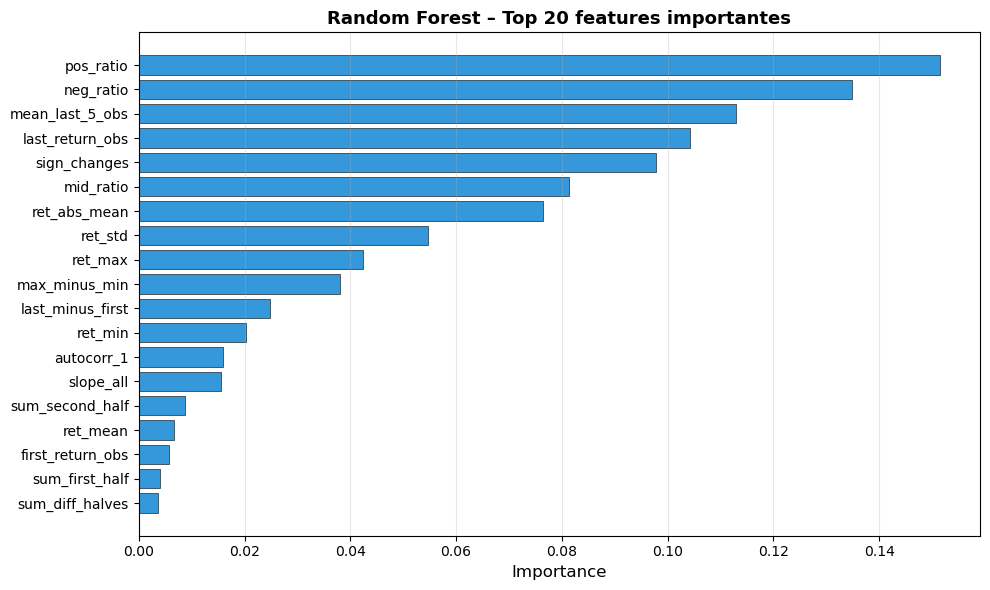

         feature  importance
       pos_ratio    0.151470
       neg_ratio    0.134918
 mean_last_5_obs    0.112878
 last_return_obs    0.104297
    sign_changes    0.097837
       mid_ratio    0.081430
    ret_abs_mean    0.076485
         ret_std    0.054670
         ret_max    0.042475
   max_minus_min    0.038056
last_minus_first    0.024786
         ret_min    0.020205
      autocorr_1    0.015880
       slope_all    0.015595
 sum_second_half    0.008774
        ret_mean    0.006657
first_return_obs    0.005817
  sum_first_half    0.004072
 sum_diff_halves    0.003696


In [ ]:
# ─────────────────────────────────────────────────────────────
# 7.1 Feature importance – Random Forest et HGB (permutation)
# ─────────────────────────────────────────────────────────────
def infer_feature_names(reference_X):
    if isinstance(reference_X, pd.DataFrame):
        return reference_X.columns.tolist()
    return [f'feature_{i}' for i in range(reference_X.shape[1])]


def plot_feature_importance_from_values(values, feature_names, title, top_n=20, color='#3498db'):
    values = np.asarray(values)
    idx = np.argsort(values)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([feature_names[i] for i in idx][::-1], values[idx][::-1], color=color,
            edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({'feature': feature_names, 'importance': values}).sort_values('importance', ascending=False).head(top_n)

feature_names_model = infer_feature_names(X_train)

print('=== Random Forest – Feature Importance ===')
imp_rf = plot_feature_importance_from_values(
    best_rf.feature_importances_,
    feature_names_model,
    'Random Forest – Top 20 features importantes',
    color='#3498db'
)
print(imp_rf.to_string(index=False))


L’analyse des importances montre que le modèle s’appuie principalement sur des variables liées à la **structure des rendements intraday** plutôt que sur des statistiques globales simples.

Les variables les plus influentes sont :
- **pos_ratio** et **neg_ratio**, qui capturent la proportion de rendements positifs et négatifs, indiquant que la **direction dominante au cours de la journée** est un signal clé ;
- **mean_last_5_obs** et **last_return_obs**, suggérant que les **derniers mouvements intraday** jouent un rôle important dans la prédiction ;
- **sign_changes**, qui mesure la fréquence des retournements, reflétant la **stabilité ou l’instabilité du marché intraday**.

Les variables de dispersion (**ret_std**, **ret_abs_mean**) et d’amplitude (**ret_max**, **max_minus_min**) ont une importance intermédiaire, indiquant que la **volatilité intraday** contribue également à la prédiction, mais dans une moindre mesure.

À l’inverse, les variables plus globales ou agrégées (**ret_mean**, **sum_first_half**, etc.) ont une faible importance, ce qui suggère que le modèle exploite davantage des **dynamiques locales et récentes** que des tendances moyennes.

Dans l’ensemble, ces résultats indiquent que la prédiction repose principalement sur des signaux de **momentum court terme** et de **structure intraday**, plutôt que sur des indicateurs globaux.

=== Hist Gradient Boosting – Permutation importance ===


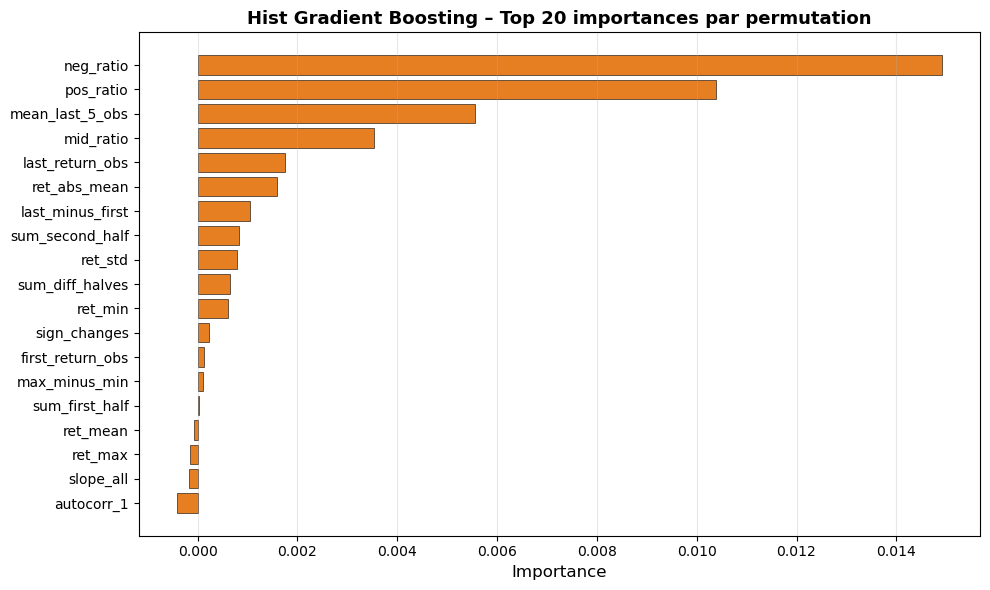

         feature  importance
       neg_ratio    0.014910
       pos_ratio    0.010390
 mean_last_5_obs    0.005560
       mid_ratio    0.003530
 last_return_obs    0.001757
    ret_abs_mean    0.001600
last_minus_first    0.001053
 sum_second_half    0.000820
         ret_std    0.000793
 sum_diff_halves    0.000650
         ret_min    0.000613
    sign_changes    0.000227
first_return_obs    0.000127
   max_minus_min    0.000117
  sum_first_half    0.000020
        ret_mean   -0.000067
         ret_max   -0.000157
       slope_all   -0.000170
      autocorr_1   -0.000413


In [ ]:
print('=== Hist Gradient Boosting – Permutation importance ===')

# Sous-échantillon de validation pour limiter le temps de calcul
n_perm_samples = min(60_000, len(X_val))
if len(X_val) > n_perm_samples:
    perm_idx = np.random.RandomState(42).choice(len(X_val), size=n_perm_samples, replace=False)
    if isinstance(X_val, pd.DataFrame):
        X_val_perm = X_val.iloc[perm_idx]
    else:
        X_val_perm = X_val[perm_idx]

    if isinstance(y_val, pd.Series):
        y_val_perm = y_val.iloc[perm_idx]
    else:
        y_val_perm = y_val[perm_idx]
else:
    X_val_perm = X_val
    y_val_perm = y_val

perm_hgb = permutation_importance(
    best_hgb,
    X_val_perm,
    y_val_perm,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

imp_hgb = plot_feature_importance_from_values(
    perm_hgb.importances_mean,
    feature_names_model,
    'Hist Gradient Boosting – Top 20 importances par permutation',
    color='#e67e22'
)
print(imp_hgb.to_string(index=False))


L’analyse par permutation confirme que le modèle s’appuie principalement sur les variables de **structure directionnelle intraday**, en particulier **neg_ratio** et **pos_ratio**, qui dominent largement les importances.

Les variables liées aux **rendements récents** (**mean_last_5_obs**, **last_return_obs**) conservent également un rôle significatif, confirmant l’importance du **momentum de court terme**.

En revanche, la majorité des autres variables présentent une importance très faible, voire nulle ou légèrement négative, ce qui suggère qu’elles apportent peu d’information utile au modèle.

Dans l’ensemble, ces résultats sont cohérents avec ceux de la Random Forest et indiquent que le modèle repose sur un **nombre restreint de signaux clés**, principalement liés à la direction et à la dynamique récente des rendements intraday.

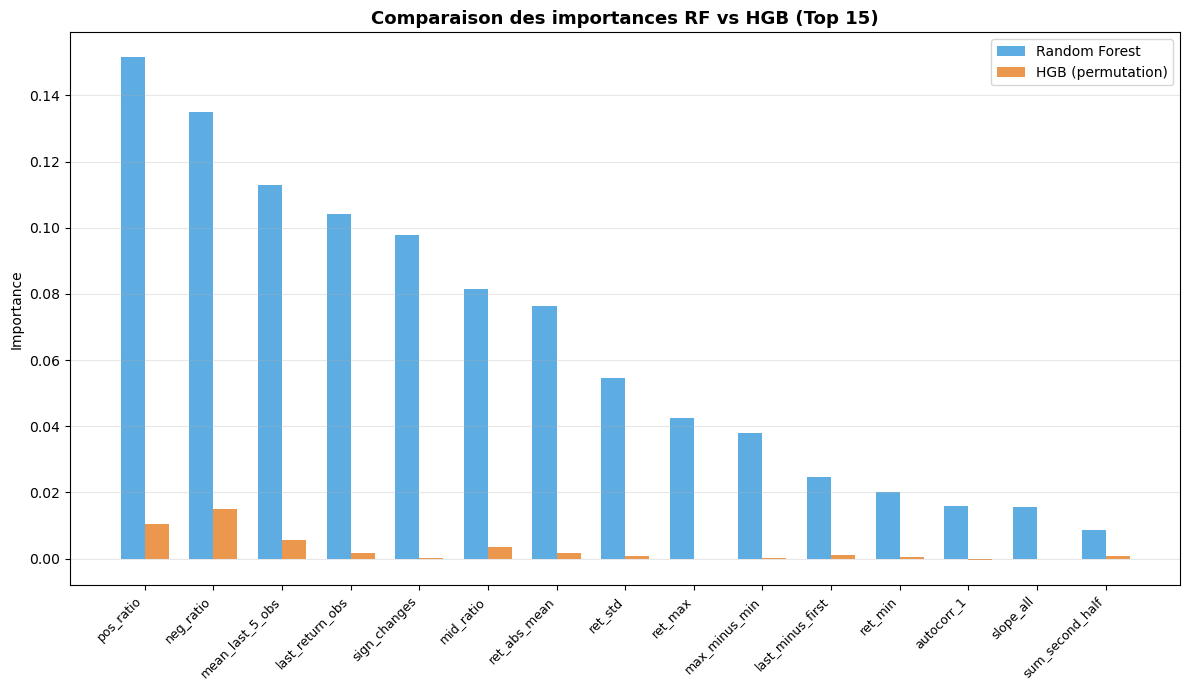

In [ ]:
# ─────────────────────────────────────────────────────────────
# 7.2 Comparaison de l'importance entre RF et HGB
# ─────────────────────────────────────────────────────────────
imp_compare = pd.DataFrame({
    'feature': feature_names_model,
    'RF': best_rf.feature_importances_,
    'HGB_perm': perm_hgb.importances_mean
}).set_index('feature').sort_values('RF', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(imp_compare))
width = 0.35
ax.bar(x - width / 2, imp_compare['RF'], width, label='Random Forest', color='#3498db', alpha=0.8)
ax.bar(x + width / 2, imp_compare['HGB_perm'], width, label='HGB (permutation)', color='#e67e22', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(imp_compare.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Comparaison des importances RF vs HGB (Top 15)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


La comparaison des importances entre la Random Forest et le Gradient Boosting met en évidence une **forte cohérence dans les variables dominantes**.

Les deux modèles accordent une importance majeure aux variables **pos_ratio** et **neg_ratio**, confirmant que la **direction dominante des rendements intraday** constitue le principal signal prédictif.  
Les variables liées au **momentum de court terme** (**mean_last_5_obs**, **last_return_obs**) apparaissent également systématiquement parmi les plus influentes.

Cependant, une différence notable réside dans la **distribution des importances** :
- la Random Forest répartit l’importance sur un plus grand nombre de variables,
- tandis que le Gradient Boosting se concentre davantage sur un **nombre restreint de features clés**, les autres ayant une contribution quasi nulle.

Ce comportement s’explique par la nature des deux approches :  
la Random Forest repose sur du **bagging**, c’est-à-dire une agrégation de nombreux arbres construits indépendamment sur des sous-échantillons de données et de variables. En moyennant leurs résultats, le modèle tend à attribuer de l’importance à plusieurs variables différentes, ce qui conduit à une **répartition plus diffuse et plus stable des importances**.  
À l’inverse, le Gradient Boosting construit les arbres de manière **séquentielle**, chaque nouvel arbre cherchant à corriger les erreurs du précédent. Ce mécanisme pousse le modèle à se focaliser progressivement sur un **petit nombre de variables très prédictives**, en concentrant fortement l’importance sur celles-ci.

Enfin, cette convergence des résultats renforce les conclusions précédentes :  
malgré la complexité des modèles utilisés, la prédiction repose sur un **nombre limité de signaux intraday**, principalement liés à la direction et à la dynamique récente des rendements.

Cela explique également pourquoi les gains de performance observés en partie 6 restent **modérés**, les modèles exploitant globalement les mêmes sources d’information.

### 7.3 Analyse croisée des importances


In [ ]:
# ─────────────────────────────────────────────────────────────
# 7.3 Top features communes RF / HGB
# ─────────────────────────────────────────────────────────────
top_k = 20

rf_ranked = pd.Series(best_rf.feature_importances_, index=feature_names_model).sort_values(ascending=False)
hgb_ranked = pd.Series(perm_hgb.importances_mean, index=feature_names_model).sort_values(ascending=False)

common_top_features = list(set(rf_ranked.head(top_k).index).intersection(set(hgb_ranked.head(top_k).index)))
common_top_features = sorted(common_top_features, key=lambda f: (rf_ranked[f] + hgb_ranked[f]), reverse=True)

common_df = pd.DataFrame({
    'feature': common_top_features,
    'RF_importance': [rf_ranked[f] for f in common_top_features],
    'HGB_perm_importance': [hgb_ranked[f] for f in common_top_features]
})

print(f'Nombre de features communes dans les top {top_k}: {len(common_top_features)}')
print(common_df.head(20).to_string(index=False))


Nombre de features communes dans les top 20: 19
         feature  RF_importance  HGB_perm_importance
       pos_ratio       0.151470             0.010390
       neg_ratio       0.134918             0.014910
 mean_last_5_obs       0.112878             0.005560
 last_return_obs       0.104297             0.001757
    sign_changes       0.097837             0.000227
       mid_ratio       0.081430             0.003530
    ret_abs_mean       0.076485             0.001600
         ret_std       0.054670             0.000793
         ret_max       0.042475            -0.000157
   max_minus_min       0.038056             0.000117
last_minus_first       0.024786             0.001053
         ret_min       0.020205             0.000613
      autocorr_1       0.015880            -0.000413
       slope_all       0.015595            -0.000170
 sum_second_half       0.008774             0.000820
        ret_mean       0.006657            -0.000067
first_return_obs       0.005817             0.00012

### Analyse croisée des importances

L’analyse croisée montre que **19 variables sur 20** sont communes entre les deux modèles, ce qui met en évidence une **forte stabilité des signaux identifiés**.

Les variables dominantes (**pos_ratio**, **neg_ratio**, **mean_last_5_obs**, **last_return_obs**) sont systématiquement en tête dans les deux modèles, confirmant que la prédiction repose sur des **facteurs robustes liés à la direction et au momentum intraday**.

En revanche, on observe des différences dans l’intensité des importances :
- la Random Forest attribue des poids plus élevés et plus diffus,
- tandis que le Gradient Boosting concentre l’information sur un nombre réduit de variables, les autres ayant un impact quasi nul.

La présence d’importances proches de zéro (ou négatives en permutation) pour certaines variables suggère qu’elles n’apportent pas d’information supplémentaire, voire introduisent du bruit dans la prédiction.

Ainsi, cette forte convergence entre modèles confirme que la performance est principalement guidée par un **noyau restreint de variables pertinentes**, ce qui explique les gains limités observés lors du passage à des modèles plus complexes.

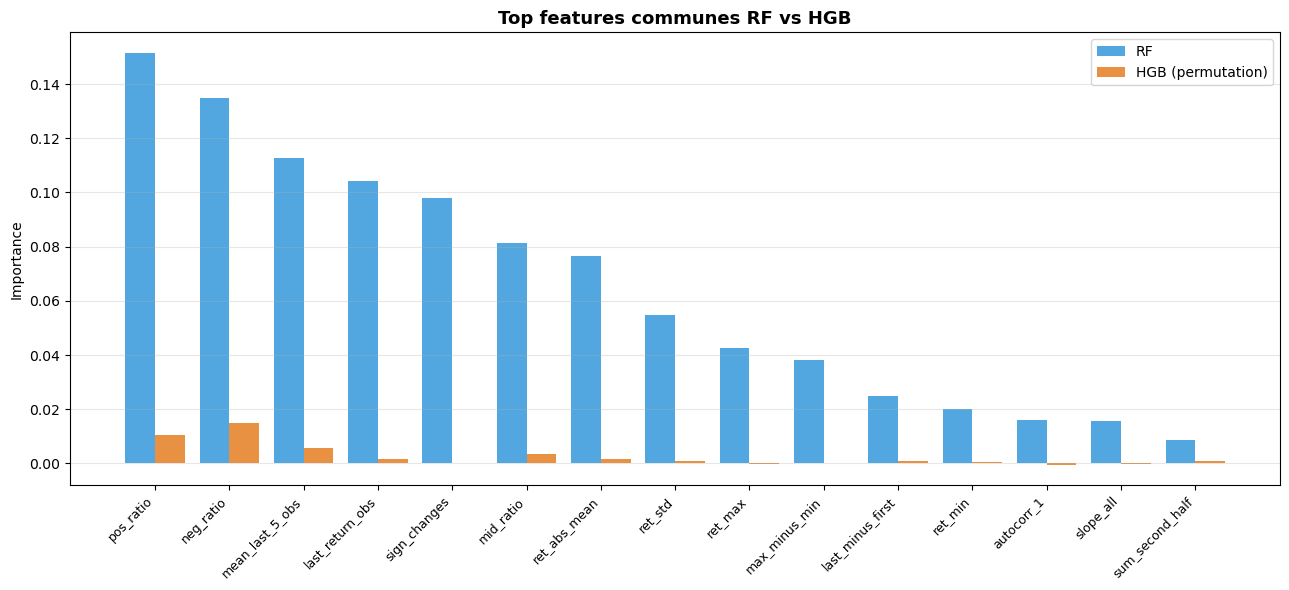

In [ ]:
# ─────────────────────────────────────────────────────────────
# Visualisation: importances comparées sur features communes
# ─────────────────────────────────────────────────────────────
if len(common_df) > 0:
    plot_df = common_df.head(15).copy()
    x = np.arange(len(plot_df))
    width = 0.4

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - width / 2, plot_df['RF_importance'], width, label='RF', color='#3498db', alpha=0.85)
    ax.bar(x + width / 2, plot_df['HGB_perm_importance'], width, label='HGB (permutation)', color='#e67e22', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['feature'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Importance')
    ax.set_title('Top features communes RF vs HGB', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


Ce graphique confirme visuellement la forte cohérence entre les deux modèles sur les variables les plus importantes.  
On observe également que le Gradient Boosting concentre davantage l’importance sur un nombre réduit de features, contrairement à la Random Forest qui la répartit plus largement.

Corrélation RF vs HGB (importances): 0.7778


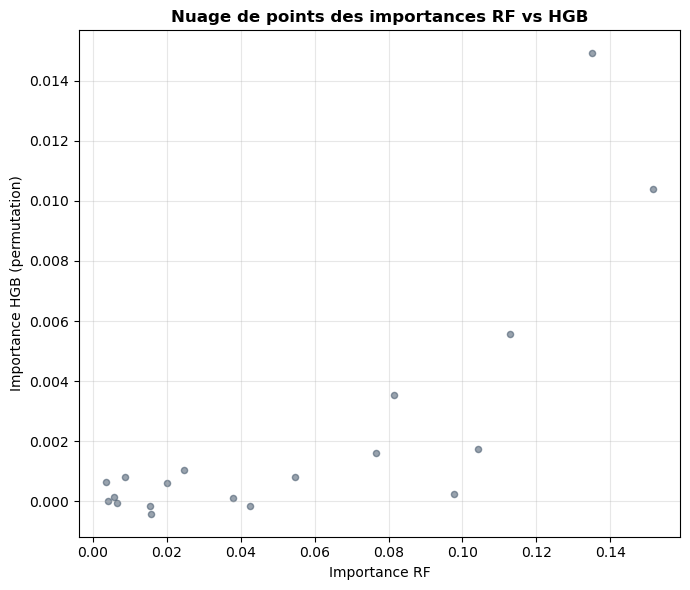

In [ ]:
# ─────────────────────────────────────────────────────────────
# Corrélation des importances RF vs HGB
# ─────────────────────────────────────────────────────────────
importance_compare_full = pd.DataFrame({
    'feature': feature_names_model,
    'RF_importance': best_rf.feature_importances_,
    'HGB_perm_importance': perm_hgb.importances_mean
})

corr_importances = importance_compare_full[['RF_importance', 'HGB_perm_importance']].corr().iloc[0, 1]
print(f'Corrélation RF vs HGB (importances): {corr_importances:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    importance_compare_full['RF_importance'],
    importance_compare_full['HGB_perm_importance'],
    alpha=0.5,
    s=20,
    color='#34495e'
)
ax.set_xlabel('Importance RF')
ax.set_ylabel('Importance HGB (permutation)')
ax.set_title('Nuage de points des importances RF vs HGB', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


La corrélation entre les importances des variables issues de la Random Forest et du Gradient Boosting atteint **0.7778**, ce qui indique une **forte cohérence globale** entre les deux modèles.

Le nuage de points confirme cette relation positive : les variables les plus importantes pour la Random Forest tendent également à l’être pour le Gradient Boosting, malgré des différences d’échelle.

Ce résultat renforce l’idée que les deux modèles identifient des **structures similaires dans les données**, reposant sur un ensemble commun de variables pertinentes.

Variables nécessaires pour 90% d'importance cumulée (RF): 11
Variables nécessaires pour 95% d'importance cumulée (RF): 13


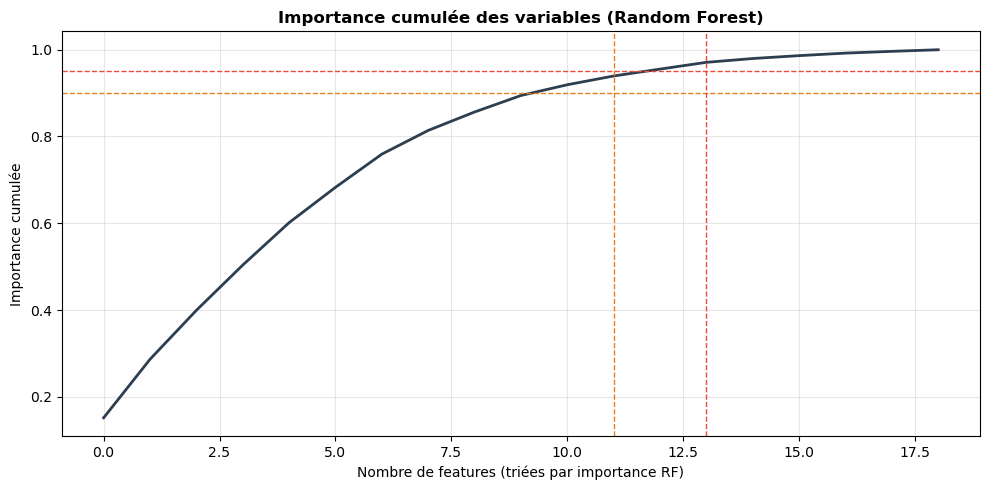

In [ ]:
# ─────────────────────────────────────────────────────────────
# Importance cumulée (RF): combien de variables expliquent l'essentiel
# ─────────────────────────────────────────────────────────────
rf_importance_sorted = np.sort(best_rf.feature_importances_)[::-1]
rf_cumulative_importance = np.cumsum(rf_importance_sorted)

threshold_90 = int(np.searchsorted(rf_cumulative_importance, 0.9) + 1)
threshold_95 = int(np.searchsorted(rf_cumulative_importance, 0.95) + 1)

print(f"Variables nécessaires pour 90% d'importance cumulée (RF): {threshold_90}")
print(f"Variables nécessaires pour 95% d'importance cumulée (RF): {threshold_95}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rf_cumulative_importance, color='#2c3e50', linewidth=2)
ax.axhline(0.9, color='#e67e22', linestyle='--', linewidth=1)
ax.axhline(0.95, color='#e74c3c', linestyle='--', linewidth=1)
ax.axvline(threshold_90, color='#e67e22', linestyle='--', linewidth=1)
ax.axvline(threshold_95, color='#e74c3c', linestyle='--', linewidth=1)
ax.set_xlabel('Nombre de features (triées par importance RF)')
ax.set_ylabel('Importance cumulée')
ax.set_title('Importance cumulée des variables (Random Forest)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


L’analyse de l’importance cumulée montre que **seulement 11 variables** permettent d’expliquer **90% de l’importance totale**, et **13 variables** suffisent pour atteindre **95%**.

Cela confirme que le modèle repose sur un **nombre limité de variables clés**, en cohérence avec les analyses précédentes sur les importances et leur stabilité entre modèles.

Ainsi, une grande partie des variables apporte une contribution marginale, ce qui suggère une **redondance de l’information** ou la présence de variables peu informatives.

Ce résultat met en évidence que le signal prédictif est **principalement concentré sur un petit nombre de variables**, les autres ayant un impact faible voire négligeable sur les performances du modèle.

## 8. Comparaison finale des performances et interprétation

### 8.1 Tableau récapitulatif


In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.1 Récapitulatif des performances
# ─────────────────────────────────────────────────────────────
results = {
    'Logistic Regression (base)': {
        'acc_train': acc_train_logreg_base,
        'acc_val': acc_val_logreg_base,
        'bacc_val': bacc_val_logreg_base,
        'f1_val': f1_val_logreg_base,
        'auc_val': auc_val_logreg_base,
    },
    'Logistic Regression (opt)': {
        'acc_train': acc_train_logreg,
        'acc_val': acc_logreg_best,
        'bacc_val': bacc_logreg_best,
        'f1_val': f1_logreg_best,
        'auc_val': auc_logreg_best,
    },
    'Logistic + clusters (opt)': {
        'acc_train': results_logreg_cluster['acc_train'],
        'acc_val': results_logreg_cluster['acc_val'],
        'bacc_val': results_logreg_cluster['bacc_val'],
        'f1_val': results_logreg_cluster['f1_val'],
        'auc_val': results_logreg_cluster['auc_val'],
    },
    'Random Forest (base)': {
        'acc_train': acc_train_rf,
        'acc_val': acc_rf,
        'bacc_val': bacc_rf,
        'f1_val': f1_rf,
        'auc_val': auc_rf,
    },
    'Random Forest (opt)': {
        'acc_train': acc_train_best_rf,
        'acc_val': acc_val_best_rf,
        'bacc_val': bacc_val_best_rf,
        'f1_val': f1_val_best_rf,
        'auc_val': auc_val_best_rf,
    },
    'HGB (base)': {
        'acc_train': acc_train_hgb,
        'acc_val': acc_val_hgb,
        'bacc_val': bacc_val_hgb,
        'f1_val': f1_val_hgb,
        'auc_val': auc_val_hgb,
    },
    'HGB (opt)': {
        'acc_train': acc_train_best_hgb,
        'acc_val': acc_best_hgb,
        'bacc_val': bacc_best_hgb,
        'f1_val': f1_best_hgb,
        'auc_val': auc_best_hgb,
    },
}

results_df = pd.DataFrame(results).T
results_df.columns = ['Accuracy Train', 'Accuracy Val', 'Balanced Accuracy Val', 'Macro-F1 Val', 'AUC Val']
results_df = results_df.sort_values('Accuracy Val', ascending=False)

print('======================================================================================')
print('RÉCAPITULATIF DES PERFORMANCES')
print('======================================================================================')
print(results_df.round(4).to_string())

RÉCAPITULATIF DES PERFORMANCES
                            Accuracy Train  Accuracy Val  Balanced Accuracy Val  Macro-F1 Val  AUC Val
HGB (opt)                           0.4806        0.4713                 0.4336        0.4157   0.6572
HGB (base)                          0.4849        0.4710                 0.4335        0.4164   0.6573
Random Forest (opt)                 0.4796        0.4701                 0.4304        0.4013   0.6562
Logistic + clusters (best)          0.4607        0.4617                 0.4386        0.4335   0.6481
Logistic Regression (opt)           0.4580        0.4589                 0.4338        0.4280   0.6453
Logistic Regression (base)          0.4578        0.4586                 0.4337        0.4279   0.6453
Random Forest (base)                0.4633        0.4566                 0.4399        0.4398   0.6550


Le tableau récapitulatif met en évidence des performances relativement proches entre l’ensemble des modèles testés.

Les modèles les plus performants en termes d’accuracy de validation sont les approches de **Gradient Boosting (HGB)** et de **Random Forest optimisée**, avec des scores autour de **0.47**, légèrement supérieurs aux modèles logistiques.

Cependant, les écarts restent **faibles (de l’ordre de 1 point de pourcentage)**, ce qui indique que l’apport des modèles non linéaires, bien que réel, demeure limité.

Par ailleurs, la **balanced accuracy** ne montrent pas d’amélioration significative, et restent globalement proches entre tous les modèles. En revanche, en ce qui concerne la **macro-F1** on observe une déterioration de celle-ci pour le Random Forest et l'HGB, indiquant un excès de faux positifs ou un manque de détection de certaines classes.
Cela confirme que les modèles rencontrent des difficultés similaires pour prédire certaines classes, notamment les classes extrêmes.

On observe également que tous les modèles présentent un **écart train/validation faible**, indiquant une bonne capacité de généralisation et l’absence de surapprentissage marqué.

Ainsi, malgré des différences de complexité importantes entre les modèles, leurs performances restent proches, ce qui suggère que la limite principale provient de la **qualité du signal prédictif**, plutôt que du choix du modèle.

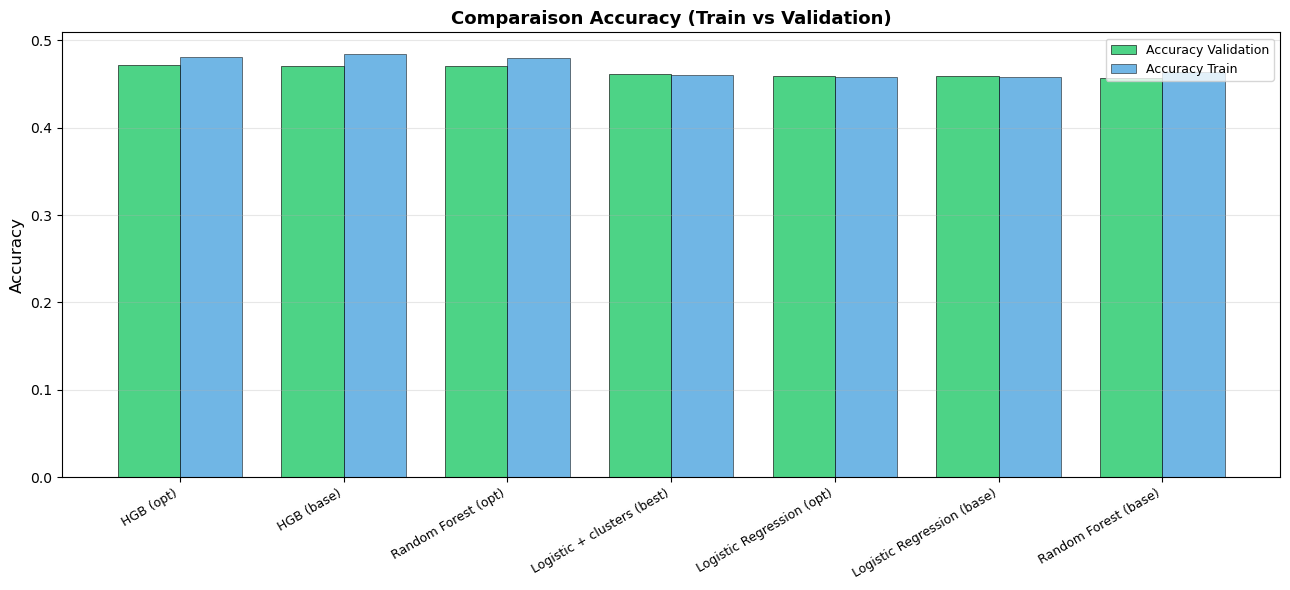

In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.1 Visualisation: ranking Accuracy train/val
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

model_names = results_df.index.tolist()
acc_val_values = results_df['Accuracy Val'].values
acc_train_values = results_df['Accuracy Train'].values

x = np.arange(len(model_names))
bar_width = 0.38

ax.bar(x - bar_width / 2, acc_val_values, bar_width, label='Accuracy Validation',
       color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + bar_width / 2, acc_train_values, bar_width, label='Accuracy Train',
       color='#3498db', alpha=0.70, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparaison Accuracy (Train vs Validation)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Ce graphique met en évidence la proximité entre les performances en entraînement et en validation pour l’ensemble des modèles, confirmant une **bonne capacité de généralisation**.

On observe également que les modèles les plus complexes (HGB, Random Forest) obtiennent les meilleures performances, mais avec un gain relativement limité par rapport aux modèles plus simples.

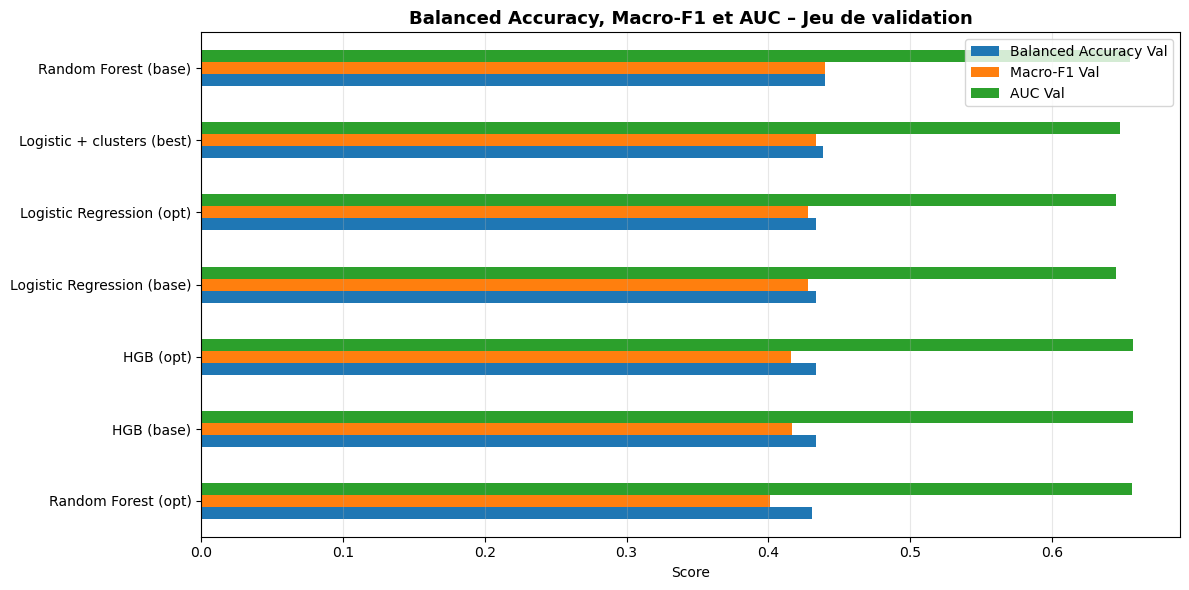

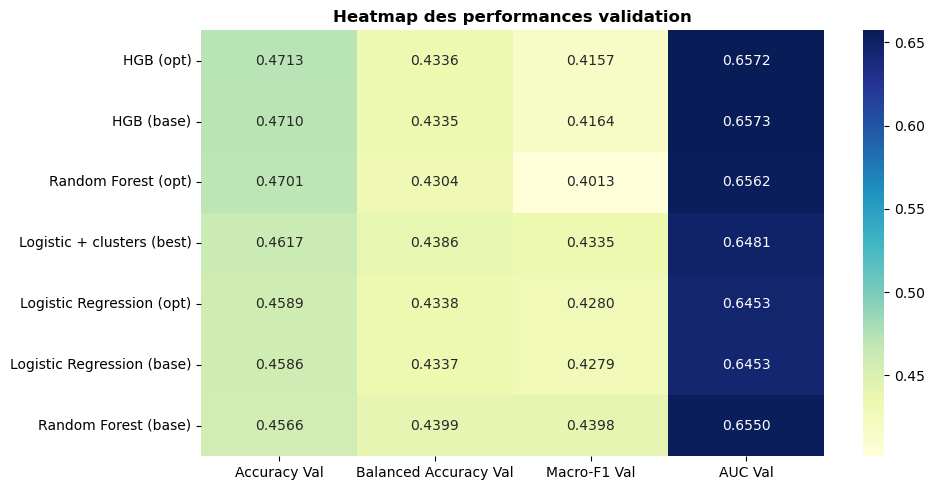

In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.2 Balanced accuracy, Macro-F1 et AUC multiclass
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Balanced Accuracy Val', 'Macro-F1 Val', 'AUC Val']].sort_values('Balanced Accuracy Val').plot(
    kind='barh', ax=ax
)
ax.set_title('Balanced Accuracy, Macro-F1 et AUC – Jeu de validation', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

validation_metrics = results_df[['Accuracy Val', 'Balanced Accuracy Val', 'Macro-F1 Val', 'AUC Val']]
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(validation_metrics, annot=True, fmt='.4f', cmap='YlGnBu', cbar=True, ax=ax)
ax.set_title('Heatmap des performances validation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Les métriques de **balanced accuracy** et de **macro-F1** confirment que les performances des modèles restent globalement proches, sans amélioration nette des modèles les plus complexes.

Le modèle **Logistic + clusters** présente même les meilleurs résultats sur ces métriques, suggérant une meilleure prise en compte de l’équilibre entre les classes.

À l’inverse, les modèles de type Random Forest et Gradient Boosting, bien que légèrement meilleurs en accuracy, n’apportent pas de gain significatif en termes de performance globale sur l’ensemble des classes.

Cela confirme que le principal défi du problème réside dans la **prédiction des classes minoritaires**, et que les gains en accuracy ne se traduisent pas nécessairement par une amélioration uniforme du modèle.

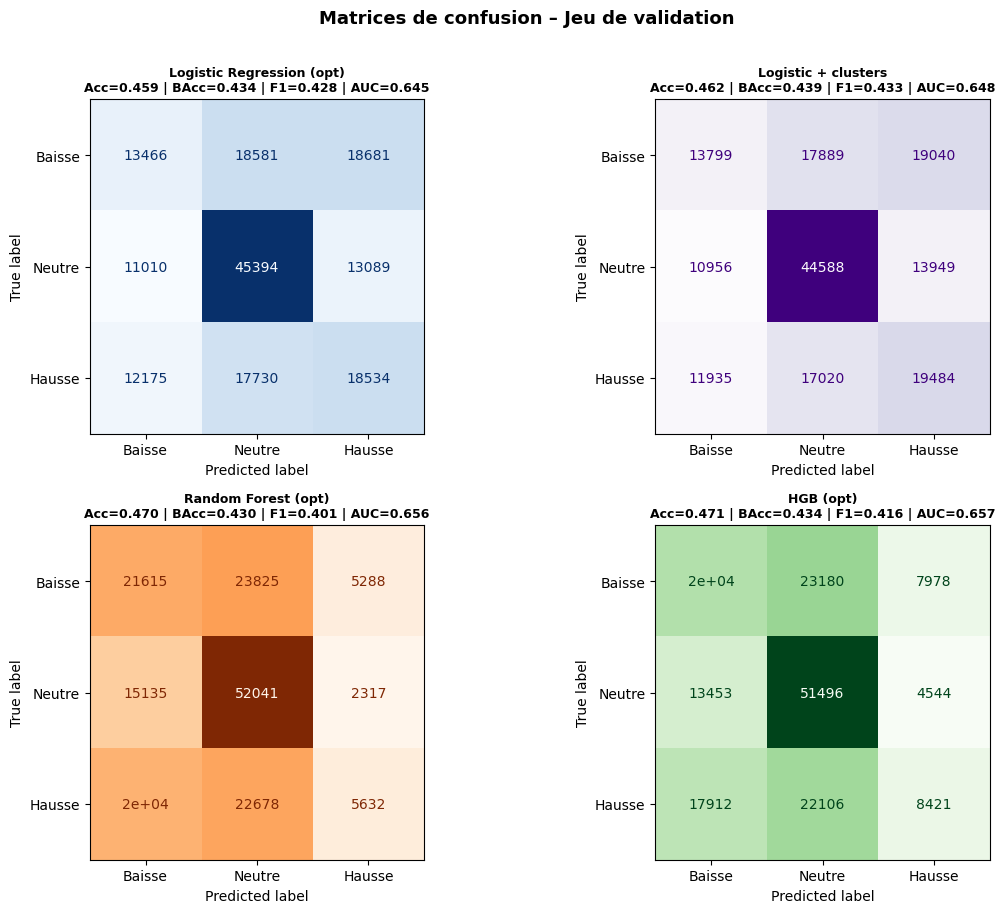

In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.3 Matrices de confusion des meilleurs modèles
# ─────────────────────────────────────────────────────────────
comparison_models = {
    'Logistic Regression (opt)': (best_logreg, val_feats, 'Blues'),
    'Logistic + clusters': (best_logreg_cluster, cluster_feature_sets[best_variant_name][1], 'Purples'),
    'Random Forest (opt)': (best_rf, X_val, 'Oranges'),
    'HGB (opt)': (best_hgb, X_val, 'Greens'),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (name, (model, X_val_model, cmap)) in zip(axes, comparison_models.items()):
    y_pred = model.predict(X_val_model)
    cm = confusion_matrix(y_val, y_pred, labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baisse', 'Neutre', 'Hausse'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)

    acc = accuracy_score(y_val, y_pred)
    bacc = balanced_accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    auc_val = compute_multiclass_auc(model, X_val_model, y_val)
    ax.set_title(
        f'{name}\nAcc={acc:.3f} | BAcc={bacc:.3f} | F1={macro_f1:.3f} | AUC={auc_val:.3f}',
        fontsize=9,
        fontweight='bold',
    )

plt.suptitle('Matrices de confusion – Jeu de validation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Les matrices de confusion confirment que tous les modèles ont des comportements similaires face aux différentes classes.

La classe **Neutre (0)** est nettement mieux prédite, avec un nombre élevé de bonnes classifications, ce qui s’explique par sa fréquence plus importante dans les données.

En revanche, les classes **Baisse (-1)** et surtout **Hausse (1)** sont plus difficiles à prédire, avec de nombreuses confusions vers la classe neutre.

Les modèles ensemblistes (Random Forest et HGB) améliorent légèrement la détection des classes extrêmes par rapport à la régression logistique, mais ces gains restent limités.

Ainsi, ces résultats confirment que la principale difficulté du problème réside dans la **discrimination des mouvements directionnels**, en particulier pour les signaux de hausse.

## 9. Conclusion et interprétation des résultats

### 9.1 Synthèse des performances

| Modèle | Accuracy Val | Commentaire |
|---|---|---|
| Benchmark | ~0.412 | Benchmark fourni par le CFM pour le challenge|
| Régression Logistique multinomiale | 0.4589 | Modèle linéaire robuste mais limité pour capter les non-linéarités |
| Logistic + clusters | 0.4617 | Légère amélioration grâce à l’ajout d’information structurelle |
| Random Forest (opt) | 0.4701 | Bon compromis biais/variance, capte les interactions non linéaires |
| HGB (opt) | **0.4713** | Meilleure performance en validation mais plus sensible au sur-apprentissage |

**Important :** bien que le modèle **HGB** obtienne la meilleure performance sur les données de validation, l’évaluation sur les données de test montre que le **Random Forest généralise mieux** et atteint une performance supérieure hors échantillon.  
Le Random Forest est donc retenu comme modèle final, car il offre une meilleure robustesse dans un contexte de changement de distribution des données.


### 9.2 Enseignements principaux

1. **Le problème étudié est un problème de classification à 3 classes (`reod`)**, reposant sur des trajectoires intraday de rendements, caractérisées par un fort bruit et une faible persistance.

2. **Le signal prédictif est faible et diffus**, comme en témoignent les écarts limités de performance entre les modèles. Cela reflète la difficulté structurelle à anticiper les mouvements de marché à court terme, en particulier sur des horizons intraday.

3. **Les variables les plus informatives capturent essentiellement la direction et le momentum intraday** (ratios positifs/négatifs, rendements récents).  
Cela suggère que l’information utile ne réside pas dans les niveaux de rendement eux-mêmes, mais dans la **structure directionnelle et la dynamique récente de la trajectoire**.

4. **La forte redondance entre variables** (confirmée par l’analyse des importances) indique que plusieurs features décrivent des aspects proches du même signal, ce qui limite les gains potentiels liés à l’ajout de nouvelles variables simples.

5. **Le clustering apporte une information structurelle complémentaire**, en identifiant des régimes intraday, mais son impact reste limité car ces régimes sont déjà partiellement capturés par les variables construites.

6. **Les modèles ensemblistes (Random Forest, HGB)** permettent de mieux capter les interactions non linéaires, mais leur gain reste modéré. Cela indique que la contrainte principale ne vient pas du modèle mais de la **qualité et de la richesse du signal disponible**.

7. **La divergence entre validation et test met en évidence un phénomène de sur-apprentissage**, particulièrement marqué pour le HGB.  
Cela souligne l’importance d’évaluer les modèles dans un cadre réaliste où les données hors échantillon présentent des caractéristiques différentes.


### 9.3 Pistes d'amélioration

- Enrichir le feature engineering avec des descripteurs plus avancés de trajectoires :
  autocorrélations à plusieurs lags, détection de ruptures, drawdowns intraday, temps de retour à zéro ;

- Explorer d'autres modèles séquentiels capables de mieux prédire les rendements.

- Intégrer des variables de contexte (volatilité de marché, effets calendaires, caractéristiques des actifs) afin d’augmenter le contenu informationnel du modèle.

- Approfondir la sélection et l’évaluation des variables (feature selection), afin d’identifier les variables les plus pertinentes et réduire la redondance.

### 9.4 Conclusion générale

Ce projet met en évidence la difficulté intrinsèque de prédire la direction des prix en fin de session à partir de données intraday.

Malgré l’utilisation de modèles avancés et d’un feature engineering structuré, les performances restent proches les unes des autres, ce qui confirme que le **signal prédictif est faible, instable et fortement bruité** dans ce type de données financières.

L’analyse met en évidence que la performance ne dépend pas uniquement du choix du modèle, mais surtout de sa capacité à **généraliser dans un environnement non stationnaire**.  
Dans ce cadre, le Random Forest apparaît comme le modèle le plus adapté, offrant un bon compromis entre flexibilité et robustesse.

Enfin, les résultats suggèrent que les gains futurs ne proviendront pas uniquement d’une complexification des modèles, mais davantage d’une **meilleure représentation de la dynamique intraday** et de l’intégration d’informations de marché complémentaires.